# Real Final: 6개 스테이션 데이터 로드

이 노트북은 새로운 분석을 시작하기 위한 초기 파일이다.
우선 6개 스테이션의 원본 데이터를 불러오고, 파일 존재 여부와 기본 행 수만 확인한다.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from pathlib import Path
from IPython.display import display

font_candidates = ['AppleGothic', 'Malgun Gothic', 'NanumGothic']
available_fonts = {f.name for f in fm.fontManager.ttflist}
selected_font = next((font for font in font_candidates if font in available_fonts), None)
if selected_font:
    plt.rcParams['font.family'] = selected_font
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (14, 4)

base_path = Path('../../../Data/sort_data/preprocessed_6station')
station_info = {
    'ST-481': '상현',
    'ST-2425': '다원',
    'ST-1331': '찬솔',
    'ST-454': '신영',
    'ST-453': '혜전',
    'ST-2264': '광태',
}
station_ids = list(station_info.keys())

print('selected_font:', selected_font)
print('base_path:', base_path)
print('station_ids:', station_ids)


selected_font: AppleGothic
base_path: ../../../Data/sort_data/preprocessed_6station
station_ids: ['ST-481', 'ST-2425', 'ST-1331', 'ST-454', 'ST-453', 'ST-2264']


## 2024 데이터 로드

각 스테이션의 2024 CSV를 불러오고, 파일 경로와 행 수를 확인한다.


In [2]:
station_raw_2024 = {}
load_summary_2024 = []

for station_id in station_ids:
    path = base_path / f'{station_id}.csv'
    df = pd.read_csv(path)
    station_raw_2024[station_id] = df
    load_summary_2024.append({
        'station_id': station_id,
        'station_name': station_info[station_id],
        'file_name': path.name,
        'rows': len(df),
        'cols': len(df.columns),
        'columns_preview': ', '.join(df.columns[:8]),
    })

load_summary_2024 = pd.DataFrame(load_summary_2024)
display(load_summary_2024)


,station_id,station_name,file_name,rows,cols,columns_preview
0,ST-481,상현,ST-481.csv,71631,40,"기준_날짜, 시간대, 집계_기준, 시작_대여소_ID, 종료_대여소_ID, 전체_이용..."
1,ST-2425,다원,ST-2425.csv,40888,40,"기준_날짜, 시간대, 집계_기준, 시작_대여소_ID, 종료_대여소_ID, 전체_이용..."
2,ST-1331,찬솔,ST-1331.csv,82158,40,"기준_날짜, 시간대, 집계_기준, 시작_대여소_ID, 종료_대여소_ID, 전체_이용..."
3,ST-454,신영,ST-454.csv,102213,40,"기준_날짜, 시간대, 집계_기준, 시작_대여소_ID, 종료_대여소_ID, 전체_이용..."
4,ST-453,혜전,ST-453.csv,94823,40,"기준_날짜, 시간대, 집계_기준, 시작_대여소_ID, 종료_대여소_ID, 전체_이용..."
5,ST-2264,광태,ST-2264.csv,147253,28,"기준_날짜, 시간대, 집계_기준, 시작_대여소_ID, 종료_대여소_ID, 전체_이용..."


## 2025 데이터 로드

각 스테이션의 2025 CSV도 함께 불러오고, 테스트용 데이터가 정상적으로 존재하는지 확인한다.


In [3]:
station_raw_2025 = {}
load_summary_2025 = []

for station_id in station_ids:
    path = base_path / f'{station_id}_2025.csv'
    df = pd.read_csv(path)
    station_raw_2025[station_id] = df
    load_summary_2025.append({
        'station_id': station_id,
        'station_name': station_info[station_id],
        'file_name': path.name,
        'rows': len(df),
        'cols': len(df.columns),
        'columns_preview': ', '.join(df.columns[:8]),
    })

load_summary_2025 = pd.DataFrame(load_summary_2025)
display(load_summary_2025)


,station_id,station_name,file_name,rows,cols,columns_preview
0,ST-481,상현,ST-481_2025.csv,62613,28,"기준_날짜, 시간대, 집계_기준, 시작_대여소_ID, 종료_대여소_ID, 전체_이용..."
1,ST-2425,다원,ST-2425_2025.csv,38357,28,"기준_날짜, 시간대, 집계_기준, 시작_대여소_ID, 종료_대여소_ID, 전체_이용..."
2,ST-1331,찬솔,ST-1331_2025.csv,81522,28,"기준_날짜, 시간대, 집계_기준, 시작_대여소_ID, 종료_대여소_ID, 전체_이용..."
3,ST-454,신영,ST-454_2025.csv,88231,28,"기준_날짜, 시간대, 집계_기준, 시작_대여소_ID, 종료_대여소_ID, 전체_이용..."
4,ST-453,혜전,ST-453_2025.csv,78312,28,"기준_날짜, 시간대, 집계_기준, 시작_대여소_ID, 종료_대여소_ID, 전체_이용..."
5,ST-2264,광태,ST-2264_2025.csv,142934,28,"기준_날짜, 시간대, 집계_기준, 시작_대여소_ID, 종료_대여소_ID, 전체_이용..."


## 주차 컬럼 추가

주차별 가중치를 주기 전에, 각 데이터프레임에 공통으로 사용할 시간 기준 컬럼을 먼저 만든다.

추가되는 컬럼은 다음과 같다.
- `timestamp`: 분석 기준 시각
- `연도`: ISO 기준 연도
- `주차`: ISO 기준 주차
- `연도_주차`: `YYYY-WW` 형태 식별자

`timestamp`가 없으면 `기준_날짜 + 시간대`로 다시 만든다.


In [4]:
def add_week_columns(df):
    df = df.copy()
    if 'timestamp' in df.columns:
        df['timestamp'] = pd.to_datetime(df['timestamp'])
    else:
        df['기준_날짜'] = pd.to_datetime(df['기준_날짜'])
        if '시간대' in df.columns:
            df['timestamp'] = df['기준_날짜'] + pd.to_timedelta(df['시간대'], unit='h')
        else:
            df['timestamp'] = df['기준_날짜']

    iso = df['timestamp'].dt.isocalendar()
    df['연도'] = iso.year.astype(int)
    df['주차'] = iso.week.astype(int)
    df['연도_주차'] = df['연도'].astype(str) + '-' + df['주차'].astype(str).str.zfill(2)
    return df

station_week_2024 = {}
station_week_2025 = {}
week_summary_rows = []

for station_id in station_ids:
    df_2024 = add_week_columns(station_raw_2024[station_id])
    df_2025 = add_week_columns(station_raw_2025[station_id])
    station_week_2024[station_id] = df_2024
    station_week_2025[station_id] = df_2025

    week_summary_rows.append({
        'station_id': station_id,
        'station_name': station_info[station_id],
        '2024_min_week': df_2024['연도_주차'].min(),
        '2024_max_week': df_2024['연도_주차'].max(),
        '2024_week_count': df_2024['연도_주차'].nunique(),
        '2025_min_week': df_2025['연도_주차'].min(),
        '2025_max_week': df_2025['연도_주차'].max(),
        '2025_week_count': df_2025['연도_주차'].nunique(),
    })

week_summary = pd.DataFrame(week_summary_rows)
display(week_summary)


,station_id,station_name,2024_min_week,2024_max_week,2024_week_count,2025_min_week,2025_max_week,2025_week_count
0,ST-481,상현,2024-01,2025-01,53,2025-02,2026-01,52
1,ST-2425,다원,2024-01,2025-01,53,2025-02,2026-01,52
2,ST-1331,찬솔,2024-01,2025-01,53,2025-02,2026-01,52
3,ST-454,신영,2024-01,2025-01,53,2025-02,2026-01,52
4,ST-453,혜전,2024-01,2025-01,53,2025-02,2026-01,52
5,ST-2264,광태,2024-01,2025-01,53,2025-02,2026-01,52


## 주차 컬럼 샘플 확인

원하는 스테이션 하나를 골라 새로 추가된 주차 컬럼이 잘 들어갔는지 확인한다.


In [5]:
sample_station_id = 'ST-481'
print('2024 with week columns:', sample_station_id)
display(station_week_2024[sample_station_id][['timestamp', '연도', '주차', '연도_주차']].head())

print('2025 with week columns:', sample_station_id)
display(station_week_2025[sample_station_id][['timestamp', '연도', '주차', '연도_주차']].head())


2024 with week columns: ST-481


,timestamp,연도,주차,연도_주차
0,2024-01-01 00:00:00,2024,1,2024-01
1,2024-01-01 00:00:00,2024,1,2024-01
2,2024-01-01 00:00:00,2024,1,2024-01
3,2024-01-01 00:00:00,2024,1,2024-01
4,2024-01-01 01:00:00,2024,1,2024-01


2025 with week columns: ST-481


,timestamp,연도,주차,연도_주차
0,2025-01-09 00:00:00,2025,2,2025-02
1,2025-01-09 00:00:00,2025,2,2025-02
2,2025-01-09 00:00:00,2025,2,2025-02
3,2025-01-09 01:00:00,2025,2,2025-02
4,2025-01-09 01:00:00,2025,2,2025-02


## 샘플 확인

원하는 스테이션 하나를 골라 앞부분 데이터를 확인할 수 있다.


In [6]:
sample_station_id = 'ST-481'
print('2024 sample:', sample_station_id)
display(station_raw_2024[sample_station_id].head())

print('2025 sample:', sample_station_id)
display(station_raw_2025[sample_station_id].head())


2024 sample: ST-481


,기준_날짜,시간대,집계_기준,시작_대여소_ID,종료_대여소_ID,전체_이용_분,전체_이용_거리,온도,습도,강수량,...,is_noon,is_rushhour,month,residential_index,business_index,tourism_index,transit_index,commute_in_index,commute_out_index,snow_flag
0,2024-01-01,0,출발시간,ST-467,ST-481,0 days 00:20:00,1930.0,-2.7,92,0.0,...,0,0,1,0.012933,0.013751,0.015535,0.0,0.0,0.0,0
1,2024-01-01,0,출발시간,ST-467,ST-481,0 days 00:20:00,1930.0,-2.7,92,0.0,...,0,0,1,0.012933,0.013751,0.015535,0.0,0.0,0.0,0
2,2024-01-01,0,출발시간,ST-481,ST-1692,0 days 00:50:00,10340.0,-2.7,92,0.0,...,0,0,1,0.012933,0.013751,0.015535,0.0,0.0,0.0,0
3,2024-01-01,0,출발시간,ST-481,ST-1692,0 days 00:50:00,10340.0,-2.7,92,0.0,...,0,0,1,0.012933,0.013751,0.015535,0.0,0.0,0.0,0
4,2024-01-01,1,출발시간,ST-481,ST-2250,0 days 00:07:00,1347.0,-1.2,87,0.0,...,0,0,1,0.012933,0.013751,0.015535,0.0,0.0,0.0,0


2025 sample: ST-481


,기준_날짜,시간대,집계_기준,시작_대여소_ID,종료_대여소_ID,전체_이용_분,전체_이용_거리,온도,습도,강수량,...,weekday_2,weekday_3,weekday_4,weekday_5,weekday_6,hour_sin,hour_cos,is_noon,is_rushhour,snow_flag
0,2025-01-09,0,출발시간,ST-1038,ST-481,0 days 00:08:00,1616,-7.4,47,0.0,...,0,1,0,0,0,0.000000,1.000000,0,0,0
1,2025-01-09,0,출발시간,ST-1038,ST-481,0 days 00:08:00,1616,-7.4,47,0.0,...,0,1,0,0,0,0.000000,1.000000,0,0,0
2,2025-01-09,0,출발시간,ST-454,ST-481,0 days 00:12:00,1130,-7.4,47,0.0,...,0,1,0,0,0,0.000000,1.000000,0,0,0
3,2025-01-09,1,출발시간,ST-481,ST-2782,0 days 00:07:00,1030,-8.9,48,0.0,...,0,1,0,0,0,0.258819,0.965926,0,0,0
4,2025-01-09,1,출발시간,ST-481,ST-2782,0 days 00:07:00,1030,-8.9,48,0.0,...,0,1,0,0,0,0.258819,0.965926,0,0,0


## 시간대별 입출입량 집계

이 단계에서는 원본 이동 로그를 시간대 단위로 다시 묶어서, 스테이션별 입출입량을 계산한다.

계산 방식은 다음과 같다.
- `station_role == 'end'` 또는 `both` 이면 `inflow`로 계산
- `station_role == 'start'` 또는 `both` 이면 `outflow`로 계산
- `total_flow = inflow + outflow`
- `net_flow = inflow - outflow`

이렇게 만든 시간대 데이터가 이후 주차별 가중치 계산의 기본 테이블이 된다.


In [7]:
def make_station_hourly_flow(df):
    work = df.copy()
    if 'timestamp' in work.columns:
        work['timestamp'] = pd.to_datetime(work['timestamp'])
    else:
        work['기준_날짜'] = pd.to_datetime(work['기준_날짜'])
        if '시간대' in work.columns:
            work['timestamp'] = work['기준_날짜'] + pd.to_timedelta(work['시간대'], unit='h')
        else:
            work['timestamp'] = work['기준_날짜']

    agg = (
        work.sort_values('timestamp')
        .groupby('timestamp')
        .agg(
            inflow=('station_role', lambda s: ((s == 'end') | (s == 'both')).sum()),
            outflow=('station_role', lambda s: ((s == 'start') | (s == 'both')).sum()),
            station_id=('station_id', 'first') if 'station_id' in work.columns else ('timestamp', 'size')
        )
    )

    if 'station_id' not in work.columns:
        agg['station_id'] = None

    full_index = pd.date_range(agg.index.min(), agg.index.max(), freq='h')
    agg = agg.reindex(full_index)
    agg.index.name = 'timestamp'
    agg[['inflow', 'outflow']] = agg[['inflow', 'outflow']].fillna(0)
    agg['station_id'] = agg['station_id'].ffill().bfill()

    hourly = agg.reset_index()
    hourly['total_flow'] = hourly['inflow'] + hourly['outflow']
    hourly['net_flow'] = hourly['inflow'] - hourly['outflow']
    iso = hourly['timestamp'].dt.isocalendar()
    hourly['연도'] = iso.year.astype(int)
    hourly['주차'] = iso.week.astype(int)
    hourly['연도_주차'] = hourly['연도'].astype(str) + '-' + hourly['주차'].astype(str).str.zfill(2)
    hourly['시간대'] = hourly['timestamp'].dt.hour
    hourly['month'] = hourly['timestamp'].dt.month
    hourly['day'] = hourly['timestamp'].dt.day
    hourly['weekday'] = hourly['timestamp'].dt.weekday
    return hourly

station_hourly_2024 = {}
station_hourly_2025 = {}
hourly_summary_rows = []

for station_id in station_ids:
    hourly_2024 = make_station_hourly_flow(station_week_2024[station_id])
    hourly_2025 = make_station_hourly_flow(station_week_2025[station_id])
    station_hourly_2024[station_id] = hourly_2024
    station_hourly_2025[station_id] = hourly_2025

    hourly_summary_rows.append({
        'station_id': station_id,
        'station_name': station_info[station_id],
        '2024_hourly_rows': len(hourly_2024),
        '2024_total_inflow': int(hourly_2024['inflow'].sum()),
        '2024_total_outflow': int(hourly_2024['outflow'].sum()),
        '2025_hourly_rows': len(hourly_2025),
        '2025_total_inflow': int(hourly_2025['inflow'].sum()),
        '2025_total_outflow': int(hourly_2025['outflow'].sum()),
    })

hourly_summary = pd.DataFrame(hourly_summary_rows)
display(hourly_summary)


,station_id,station_name,2024_hourly_rows,2024_total_inflow,2024_total_outflow,2025_hourly_rows,2025_total_inflow,2025_total_outflow
0,ST-481,상현,8784,36396,37073,8567,34913,29260
1,ST-2425,다원,8782,18194,23575,8567,18237,20866
2,ST-1331,찬솔,8784,40164,44771,8568,46345,37606
3,ST-454,신영,8784,50378,53296,8568,47361,42272
4,ST-453,혜전,8783,49525,46834,8567,42607,36979
5,ST-2264,광태,8784,76826,73954,8568,84890,60836


## 시간대별 입출입량 샘플 확인

한 스테이션의 시간대 집계 결과를 직접 확인해서 `inflow`, `outflow`, `total_flow`, `net_flow`가 정상적으로 만들어졌는지 본다.


In [8]:
sample_station_id = 'ST-481'
print('2024 hourly flow sample:', sample_station_id)
display(
    station_hourly_2024[sample_station_id][
        ['timestamp', 'station_id', '시간대', 'inflow', 'outflow', 'total_flow', 'net_flow', '연도_주차']
    ].head(12)
)


2024 hourly flow sample: ST-481


,timestamp,station_id,시간대,inflow,outflow,total_flow,net_flow,연도_주차
0,2024-01-01 00:00:00,ST-481,0,2.0,2.0,4.0,0.0,2024-01
1,2024-01-01 01:00:00,ST-481,1,0.0,3.0,3.0,-3.0,2024-01
2,2024-01-01 02:00:00,ST-481,2,3.0,0.0,3.0,3.0,2024-01
3,2024-01-01 03:00:00,ST-481,3,1.0,2.0,3.0,-1.0,2024-01
4,2024-01-01 04:00:00,ST-481,4,0.0,0.0,0.0,0.0,2024-01
5,2024-01-01 05:00:00,ST-481,5,2.0,2.0,4.0,0.0,2024-01
6,2024-01-01 06:00:00,ST-481,6,4.0,6.0,10.0,-2.0,2024-01
7,2024-01-01 07:00:00,ST-481,7,2.0,1.0,3.0,1.0,2024-01
8,2024-01-01 08:00:00,ST-481,8,2.0,0.0,2.0,2.0,2024-01
9,2024-01-01 09:00:00,ST-481,9,3.0,5.0,8.0,-2.0,2024-01


## 주차별 가중치 계산을 위한 기본 집계

이 단계에서는 실제 가중치를 바로 주기 전에, 스테이션별로 `연도_주차 + 시간대` 기준 사용량 테이블을 만든다.

이 테이블은 나중에 다음과 같은 가중치 계산에 사용할 수 있다.
- 특정 주차가 평소보다 얼마나 강한지
- 같은 시간대 기준으로 어떤 주차가 더 많이 쓰였는지
- 주차별 계절성 또는 이벤트 효과가 있는지


In [9]:
station_week_hour_2024 = {}
station_week_hour_2025 = {}
week_hour_summary_rows = []

for station_id in station_ids:
    week_hour_2024 = (
        station_hourly_2024[station_id]
        .groupby(['station_id', '연도', '주차', '연도_주차', '시간대'], as_index=False)
        [['inflow', 'outflow', 'total_flow', 'net_flow']]
        .sum()
        .sort_values(['연도', '주차', '시간대'])
        .reset_index(drop=True)
    )
    week_hour_2025 = (
        station_hourly_2025[station_id]
        .groupby(['station_id', '연도', '주차', '연도_주차', '시간대'], as_index=False)
        [['inflow', 'outflow', 'total_flow', 'net_flow']]
        .sum()
        .sort_values(['연도', '주차', '시간대'])
        .reset_index(drop=True)
    )

    station_week_hour_2024[station_id] = week_hour_2024
    station_week_hour_2025[station_id] = week_hour_2025

    week_hour_summary_rows.append({
        'station_id': station_id,
        'station_name': station_info[station_id],
        '2024_week_hour_rows': len(week_hour_2024),
        '2024_week_count': week_hour_2024['연도_주차'].nunique(),
        '2025_week_hour_rows': len(week_hour_2025),
        '2025_week_count': week_hour_2025['연도_주차'].nunique(),
    })

week_hour_summary = pd.DataFrame(week_hour_summary_rows)
display(week_hour_summary)


,station_id,station_name,2024_week_hour_rows,2024_week_count,2025_week_hour_rows,2025_week_count
0,ST-481,상현,1272,53,1248,52
1,ST-2425,다원,1272,53,1248,52
2,ST-1331,찬솔,1272,53,1248,52
3,ST-454,신영,1272,53,1248,52
4,ST-453,혜전,1272,53,1248,52
5,ST-2264,광태,1272,53,1248,52


## 주차별 기본 집계 샘플 확인

이 표는 실제로 주차별 가중치를 줄 때 사용할 기본 구조다.
`연도_주차`와 `시간대` 기준으로 합산된 입출입량을 먼저 본다.


In [10]:
sample_station_id = 'ST-481'
print('2024 week-hour flow sample:', sample_station_id)
display(station_week_hour_2024[sample_station_id].head(24))


2024 week-hour flow sample: ST-481


,station_id,연도,주차,연도_주차,시간대,inflow,outflow,total_flow,net_flow
0,ST-481,2024,1,2024-01,0,18.0,12.0,30.0,6.0
1,ST-481,2024,1,2024-01,1,13.0,7.0,20.0,6.0
2,ST-481,2024,1,2024-01,2,14.0,2.0,16.0,12.0
3,ST-481,2024,1,2024-01,3,4.0,2.0,6.0,2.0
4,ST-481,2024,1,2024-01,4,1.0,2.0,3.0,-1.0
5,ST-481,2024,1,2024-01,5,2.0,4.0,6.0,-2.0
6,ST-481,2024,1,2024-01,6,21.0,32.0,53.0,-11.0
7,ST-481,2024,1,2024-01,7,12.0,34.0,46.0,-22.0
8,ST-481,2024,1,2024-01,8,27.0,48.0,75.0,-21.0
9,ST-481,2024,1,2024-01,9,16.0,28.0,44.0,-12.0


## 스테이션별 남아 있는 컬럼 확인

이 단계에서는 스테이션별로 현재 어떤 컬럼이 남아 있는지 확인한다.
아래 표는 원본 로드 데이터와 시간대 집계 데이터의 컬럼 구성을 각각 보여준다.


In [11]:
raw_column_rows = []
hourly_column_rows = []

for station_id in station_ids:
    raw_cols_2024 = station_week_2024[station_id].columns.tolist()
    raw_cols_2025 = station_week_2025[station_id].columns.tolist()
    hourly_cols_2024 = station_hourly_2024[station_id].columns.tolist()
    hourly_cols_2025 = station_hourly_2025[station_id].columns.tolist()

    raw_column_rows.append({
        'station_id': station_id,
        'station_name': station_info[station_id],
        'dataset': 'raw_2024',
        'column_count': len(raw_cols_2024),
        'columns': ', '.join(raw_cols_2024),
    })
    raw_column_rows.append({
        'station_id': station_id,
        'station_name': station_info[station_id],
        'dataset': 'raw_2025',
        'column_count': len(raw_cols_2025),
        'columns': ', '.join(raw_cols_2025),
    })

    hourly_column_rows.append({
        'station_id': station_id,
        'station_name': station_info[station_id],
        'dataset': 'hourly_2024',
        'column_count': len(hourly_cols_2024),
        'columns': ', '.join(hourly_cols_2024),
    })
    hourly_column_rows.append({
        'station_id': station_id,
        'station_name': station_info[station_id],
        'dataset': 'hourly_2025',
        'column_count': len(hourly_cols_2025),
        'columns': ', '.join(hourly_cols_2025),
    })

raw_column_summary = pd.DataFrame(raw_column_rows)
hourly_column_summary = pd.DataFrame(hourly_column_rows)

print('원본 데이터 컬럼 구성')
display(raw_column_summary)

print('시간대 집계 데이터 컬럼 구성')
display(hourly_column_summary)


원본 데이터 컬럼 구성


,station_id,station_name,dataset,column_count,columns
0,ST-481,상현,raw_2024,43,"기준_날짜, 시간대, 집계_기준, 시작_대여소_ID, 종료_대여소_ID, 전체_이용..."
1,ST-481,상현,raw_2025,32,"기준_날짜, 시간대, 집계_기준, 시작_대여소_ID, 종료_대여소_ID, 전체_이용..."
2,ST-2425,다원,raw_2024,43,"기준_날짜, 시간대, 집계_기준, 시작_대여소_ID, 종료_대여소_ID, 전체_이용..."
3,ST-2425,다원,raw_2025,32,"기준_날짜, 시간대, 집계_기준, 시작_대여소_ID, 종료_대여소_ID, 전체_이용..."
4,ST-1331,찬솔,raw_2024,43,"기준_날짜, 시간대, 집계_기준, 시작_대여소_ID, 종료_대여소_ID, 전체_이용..."
5,ST-1331,찬솔,raw_2025,32,"기준_날짜, 시간대, 집계_기준, 시작_대여소_ID, 종료_대여소_ID, 전체_이용..."
6,ST-454,신영,raw_2024,43,"기준_날짜, 시간대, 집계_기준, 시작_대여소_ID, 종료_대여소_ID, 전체_이용..."
7,ST-454,신영,raw_2025,32,"기준_날짜, 시간대, 집계_기준, 시작_대여소_ID, 종료_대여소_ID, 전체_이용..."
8,ST-453,혜전,raw_2024,43,"기준_날짜, 시간대, 집계_기준, 시작_대여소_ID, 종료_대여소_ID, 전체_이용..."
9,ST-453,혜전,raw_2025,32,"기준_날짜, 시간대, 집계_기준, 시작_대여소_ID, 종료_대여소_ID, 전체_이용..."


시간대 집계 데이터 컬럼 구성


,station_id,station_name,dataset,column_count,columns
0,ST-481,상현,hourly_2024,13,"timestamp, inflow, outflow, station_id, total_..."
1,ST-481,상현,hourly_2025,13,"timestamp, inflow, outflow, station_id, total_..."
2,ST-2425,다원,hourly_2024,13,"timestamp, inflow, outflow, station_id, total_..."
3,ST-2425,다원,hourly_2025,13,"timestamp, inflow, outflow, station_id, total_..."
4,ST-1331,찬솔,hourly_2024,13,"timestamp, inflow, outflow, station_id, total_..."
5,ST-1331,찬솔,hourly_2025,13,"timestamp, inflow, outflow, station_id, total_..."
6,ST-454,신영,hourly_2024,13,"timestamp, inflow, outflow, station_id, total_..."
7,ST-454,신영,hourly_2025,13,"timestamp, inflow, outflow, station_id, total_..."
8,ST-453,혜전,hourly_2024,13,"timestamp, inflow, outflow, station_id, total_..."
9,ST-453,혜전,hourly_2025,13,"timestamp, inflow, outflow, station_id, total_..."


## 주차별 총이용량 가중치 생성

이 단계에서는 각 스테이션의 `주차별 총이용량(total_flow)`을 기준으로 가중치를 만든다.

가중치 계산 아이디어는 다음과 같다.
- 먼저 스테이션별 `연도_주차` 단위 `total_flow` 합계를 계산한다.
- 그 다음 스테이션별 평균 주간 총이용량을 기준값으로 둔다.
- 큰 값의 영향이 너무 커지지 않도록 내부 계산은 `log1p(total_flow)`로 변환한다.

이 노트북에서는 두 값을 같이 만든다.
- `log_weight = log1p(주차 total_flow) - log1p(스테이션 평균 주간 total_flow)`
- `week_weight = exp(log_weight)`

즉 `week_weight`가 1보다 크면 그 주차는 평균보다 강한 주차이고,
1보다 작으면 평균보다 약한 주차라고 해석하면 된다.


In [12]:
def make_week_weight_table(station_hourly_map):
    week_weight_tables = {}
    week_weight_summary_rows = []

    for station_id in station_ids:
        hourly = station_hourly_map[station_id].copy()
        weekly_total = (
            hourly.groupby(['station_id', '연도', '주차', '연도_주차'], as_index=False)['total_flow']
            .sum()
            .sort_values(['연도', '주차'])
            .reset_index(drop=True)
        )
        station_avg_week_total = weekly_total['total_flow'].mean()
        weekly_total['station_avg_week_total'] = station_avg_week_total
        weekly_total['log_week_total_flow'] = np.log1p(weekly_total['total_flow'])
        weekly_total['log_station_avg_week_total'] = np.log1p(weekly_total['station_avg_week_total'])
        weekly_total['log_weight'] = (
            weekly_total['log_week_total_flow'] - weekly_total['log_station_avg_week_total']
        )
        weekly_total['week_weight'] = np.exp(weekly_total['log_weight'])

        week_weight_tables[station_id] = weekly_total
        week_weight_summary_rows.append({
            'station_id': station_id,
            'station_name': station_info[station_id],
            'week_count': len(weekly_total),
            'avg_week_total_flow': round(station_avg_week_total, 4),
            'min_weight': round(weekly_total['week_weight'].min(), 4),
            'max_weight': round(weekly_total['week_weight'].max(), 4),
            'mean_weight': round(weekly_total['week_weight'].mean(), 4),
        })

    return week_weight_tables, pd.DataFrame(week_weight_summary_rows)

station_week_weight_2024, week_weight_summary_2024 = make_week_weight_table(station_hourly_2024)
station_week_weight_2025, week_weight_summary_2025 = make_week_weight_table(station_hourly_2025)

print('2024 주차별 가중치 요약')
display(week_weight_summary_2024)

print('2025 주차별 가중치 요약')
display(week_weight_summary_2025)


2024 주차별 가중치 요약


,station_id,station_name,week_count,avg_week_total_flow,min_weight,max_weight,mean_weight
0,ST-481,상현,53,1386.2075,0.2343,1.4677,1.0
1,ST-2425,다원,53,788.0943,0.2205,1.6728,1.0
2,ST-1331,찬솔,53,1602.5472,0.2133,1.5410,1.0
3,ST-454,신영,53,1956.1132,0.1814,1.5835,1.0
4,ST-453,혜전,53,1818.0943,0.1677,1.6602,1.0
5,ST-2264,광태,53,2844.9057,0.2073,1.5373,1.0


2025 주차별 가중치 요약


,station_id,station_name,week_count,avg_week_total_flow,min_weight,max_weight,mean_weight
0,ST-481,상현,52,1234.0962,0.2388,1.7302,1.0
1,ST-2425,다원,52,751.9808,0.2683,1.6959,1.0
2,ST-1331,찬솔,52,1614.4423,0.2649,1.5661,1.0
3,ST-454,신영,52,1723.7115,0.2487,1.6496,1.0
4,ST-453,혜전,52,1530.5000,0.2292,1.6794,1.0
5,ST-2264,광태,52,2802.4231,0.2668,1.5759,1.0


## 주차별 가중치 샘플 확인

한 스테이션의 실제 주차별 총이용량과 로그 가중치를 직접 확인한다.
여기서는 `log_weight`와 `week_weight`를 같이 보면서, 특정 주차가 평균보다 얼마나 강하거나 약한지 확인할 수 있다.


In [13]:
sample_station_id = 'ST-481'
print('2024 week weight sample:', sample_station_id)
display(station_week_weight_2024[sample_station_id].head(12))

print('2025 week weight sample:', sample_station_id)
display(station_week_weight_2025[sample_station_id].head(12))


2024 week weight sample: ST-481


,station_id,연도,주차,연도_주차,total_flow,station_avg_week_total,log_week_total_flow,log_station_avg_week_total,log_weight,week_weight
0,ST-481,2024,1,2024-01,1066.0,1386.207547,6.972606,7.235048,-0.262442,0.769171
1,ST-481,2024,2,2024-02,917.0,1386.207547,6.822197,7.235048,-0.412851,0.661761
2,ST-481,2024,3,2024-03,862.0,1386.207547,6.760415,7.235048,-0.474633,0.622113
3,ST-481,2024,4,2024-04,850.0,1386.207547,6.746412,7.235048,-0.488636,0.613463
4,ST-481,2024,5,2024-05,1213.0,1386.207547,7.101676,7.235048,-0.133372,0.875139
5,ST-481,2024,6,2024-06,735.0,1386.207547,6.601230,7.235048,-0.633818,0.530562
6,ST-481,2024,7,2024-07,1105.0,1386.207547,7.008505,7.235048,-0.226543,0.797285
7,ST-481,2024,8,2024-08,602.0,1386.207547,6.401917,7.235048,-0.833131,0.434686
8,ST-481,2024,9,2024-09,995.0,1386.207547,6.903747,7.235048,-0.331301,0.717989
9,ST-481,2024,10,2024-10,1169.0,1386.207547,7.064759,7.235048,-0.170289,0.843421


2025 week weight sample: ST-481


,station_id,연도,주차,연도_주차,total_flow,station_avg_week_total,log_week_total_flow,log_station_avg_week_total,log_weight,week_weight
0,ST-481,2025,2,2025-02,324.0,1234.096154,5.783825,7.118904,-1.335079,0.263137
1,ST-481,2025,3,2025-03,800.0,1234.096154,6.685861,7.118904,-0.433043,0.648533
2,ST-481,2025,4,2025-04,955.0,1234.096154,6.862758,7.118904,-0.256146,0.774029
3,ST-481,2025,5,2025-05,374.0,1234.096154,5.926926,7.118904,-1.191978,0.303620
4,ST-481,2025,6,2025-06,487.0,1234.096154,6.190315,7.118904,-0.928589,0.395111
5,ST-481,2025,7,2025-07,756.0,1234.096154,6.629363,7.118904,-0.489541,0.612908
6,ST-481,2025,8,2025-08,772.0,1234.096154,6.650279,7.118904,-0.468625,0.625862
7,ST-481,2025,9,2025-09,895.0,1234.096154,6.797940,7.118904,-0.320964,0.725450
8,ST-481,2025,10,2025-10,912.0,1234.096154,6.816736,7.118904,-0.302168,0.739214
9,ST-481,2025,11,2025-11,1182.0,1234.096154,7.075809,7.118904,-0.043095,0.957820


## 주차별 가중치 시각화

스테이션 하나를 골라 주차별 `week_weight` 흐름을 보면,
어떤 주차가 평균보다 강한지 또는 약한지 한눈에 확인할 수 있다.


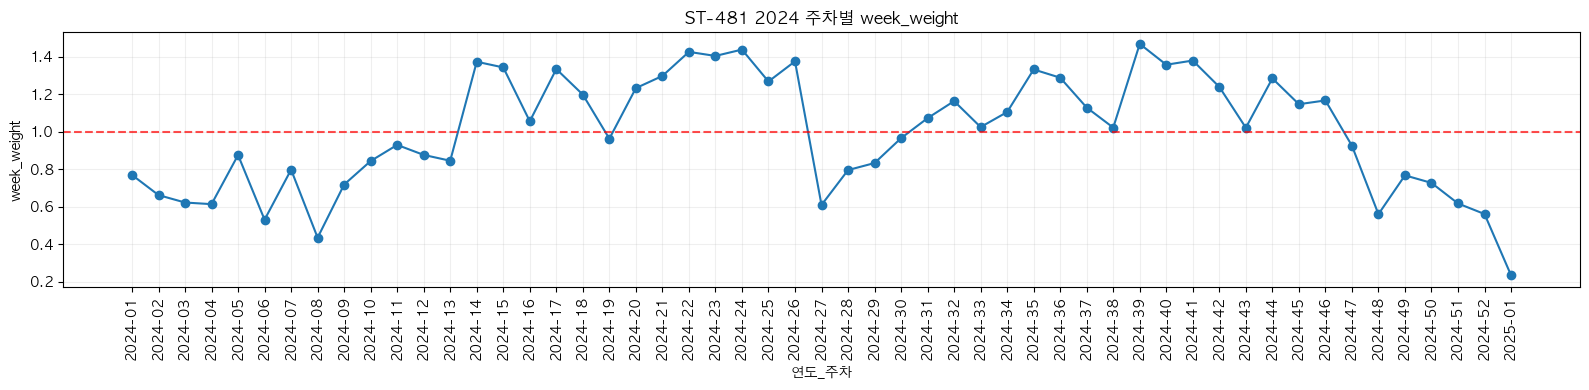

In [14]:
sample_station_id = 'ST-481'
plot_df = station_week_weight_2024[sample_station_id].copy()

fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(plot_df['연도_주차'], plot_df['week_weight'], marker='o', linewidth=1.5)
ax.axhline(1.0, color='red', linestyle='--', alpha=0.7)
ax.set_title(f'{sample_station_id} 2024 주차별 week_weight')
ax.set_xlabel('연도_주차')
ax.set_ylabel('week_weight')
ax.grid(alpha=0.2)
ax.tick_params(axis='x', rotation=90)
plt.tight_layout()
plt.show()


## 월별 시간대 패턴 생성

이 단계에서는 2024년 6개 스테이션의 시간대별 `total_flow`를 합쳐서, 월별 시간대 패턴을 만든다.

진행 방식은 다음과 같다.
- 6개 스테이션의 `hourly_2024` 데이터를 하나로 합친다.
- `month + 시간대` 기준으로 평균 `total_flow`를 계산한다.
- 이렇게 만든 월별 24시간 패턴을 비교 대상으로 사용한다.

이후 그래프와 유사도 계산은 이 월별 패턴 테이블을 기준으로 진행한다.


In [15]:
from sklearn.metrics.pairwise import cosine_similarity

combined_hourly_2024 = pd.concat(
    [station_hourly_2024[station_id].assign(source_station_id=station_id) for station_id in station_ids],
    ignore_index=True,
)

monthly_hourly_usage_2024 = (
    combined_hourly_2024
    .groupby(['month', '시간대'], as_index=False)[['inflow', 'outflow', 'total_flow', 'net_flow']]
    .mean()
    .sort_values(['month', '시간대'])
    .reset_index(drop=True)
)

monthly_hourly_pivot_2024 = (
    monthly_hourly_usage_2024
    .pivot(index='month', columns='시간대', values='total_flow')
    .sort_index()
)

print('monthly_hourly_usage_2024')
display(monthly_hourly_usage_2024.head(24))
print('monthly_hourly_pivot_2024')
display(monthly_hourly_pivot_2024)


monthly_hourly_usage_2024


,month,시간대,inflow,outflow,total_flow,net_flow
0,1,0,1.923913,2.548913,4.472826,-0.625000
1,1,1,1.376344,1.811828,3.188172,-0.435484
2,1,2,0.962366,1.516129,2.478495,-0.553763
3,1,3,0.569892,0.596774,1.166667,-0.026882
4,1,4,0.301075,0.548387,0.849462,-0.247312
5,1,5,0.510753,0.516129,1.026882,-0.005376
6,1,6,2.129032,2.150538,4.279570,-0.021505
7,1,7,3.903226,2.725806,6.629032,1.177419
8,1,8,5.698925,4.069892,9.768817,1.629032
9,1,9,3.612903,3.010753,6.623656,0.602151


monthly_hourly_pivot_2024


시간대,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
month,,,,,,,,,,,,,,,,,,,,,
1,4.472826,3.188172,2.478495,1.166667,0.849462,1.026882,4.279570,6.629032,9.768817,6.623656,...,6.408602,8.086022,9.344086,10.118280,11.709677,8.892473,7.333333,7.086022,6.446237,3.865591
2,4.040230,3.477011,2.902299,1.436782,0.856322,1.183908,3.500000,7.580460,9.051724,6.057471,...,8.120690,8.706897,10.488506,11.724138,12.896552,10.068966,8.568966,7.660920,6.781609,4.264368
3,4.672043,3.747312,3.150538,1.387097,1.059140,1.682796,5.806452,11.806452,12.688172,9.881720,...,11.129032,12.693548,14.693548,15.424731,18.037634,14.096774,10.725806,10.118280,9.086022,5.322581
4,8.016667,6.738889,3.900000,1.922222,1.577778,2.433333,8.222222,16.872222,18.611111,13.644444,...,14.950000,17.227778,19.077778,22.588889,28.522222,23.388889,19.438889,16.644444,14.794444,8.650000
5,7.731183,5.505376,3.575269,2.005376,1.666667,3.747312,9.456989,17.376344,18.559140,14.924731,...,11.591398,14.182796,18.069892,21.112903,27.639785,24.172043,20.419355,17.790323,15.215054,7.838710
6,9.644444,6.655556,4.072222,2.394444,1.722222,4.461111,10.166667,19.322222,19.677778,13.555556,...,12.722222,14.866667,20.022222,23.216667,31.872222,27.455556,24.522222,20.166667,17.672222,9.833333
7,5.381720,4.102151,2.284946,1.650538,1.241935,2.349462,6.048387,11.451613,13.586022,9.655914,...,8.284946,8.946237,11.059140,13.327957,19.069892,15.569892,13.543011,11.360215,9.193548,5.838710
8,8.290323,5.801075,3.715054,2.338710,2.209677,4.139785,7.978495,15.037634,17.446237,12.188172,...,10.344086,11.381720,14.543011,17.935484,24.500000,22.521505,18.618280,17.295699,16.075269,9.000000
9,8.638889,5.838889,3.955556,2.416667,1.766667,3.200000,6.988889,15.572222,19.066667,12.250000,...,12.033333,12.333333,17.150000,22.333333,28.377778,23.833333,20.750000,18.338889,16.883333,9.027778


## 월별 시간대 패턴 시각화

먼저 월별 시간대 패턴을 그래프로 겹쳐서 본다.
이 그래프를 통해 출퇴근 피크가 비슷한지, 특정 월만 다른 형태를 보이는지 육안으로 확인할 수 있다.


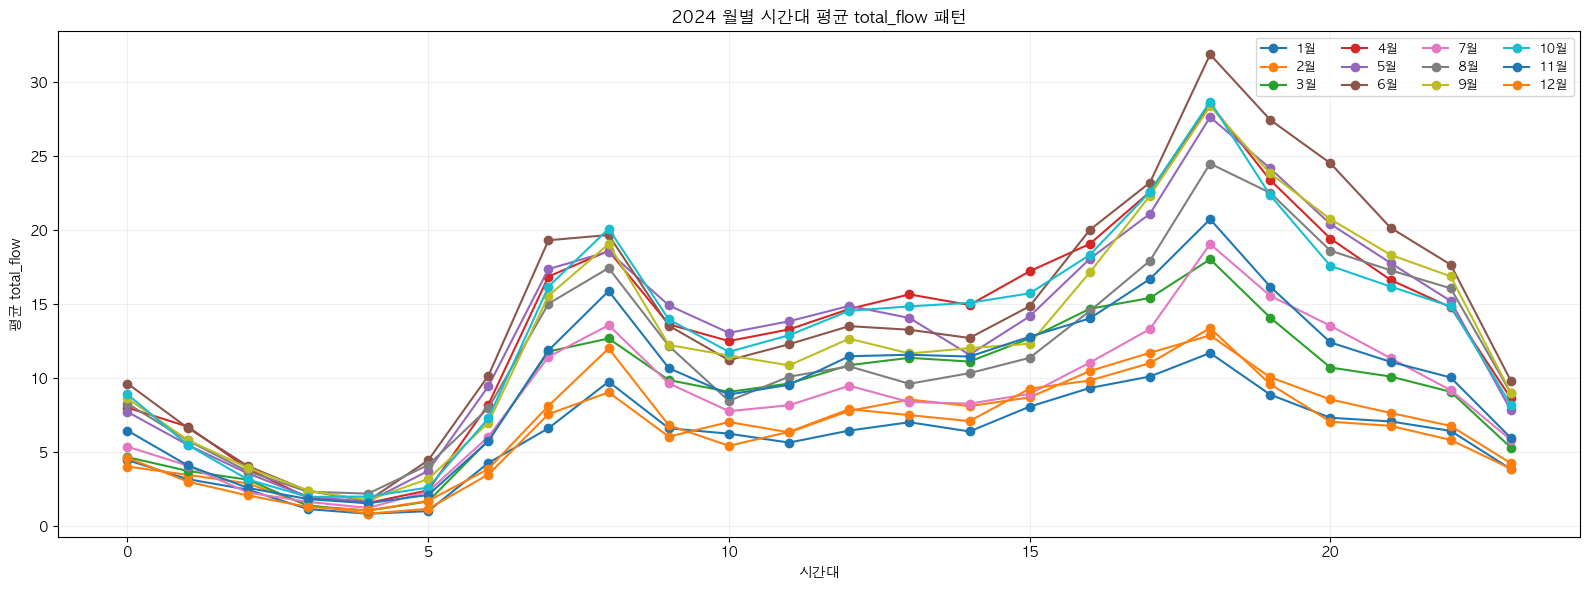

In [16]:
fig, ax = plt.subplots(figsize=(16, 6))
for month in monthly_hourly_pivot_2024.index:
    ax.plot(
        monthly_hourly_pivot_2024.columns,
        monthly_hourly_pivot_2024.loc[month].values,
        marker='o',
        linewidth=1.5,
        label=f'{month}월'
    )
ax.set_title('2024 월별 시간대 평균 total_flow 패턴')
ax.set_xlabel('시간대')
ax.set_ylabel('평균 total_flow')
ax.grid(alpha=0.2)
ax.legend(ncol=4, fontsize=9)
plt.tight_layout()
plt.show()


## 월별 개별 패턴 시각화

월별 패턴을 한 그래프에 겹쳐서 보면 전체 흐름은 보기 좋지만, 세부 차이는 놓칠 수 있다.
아래 그래프는 월별로 나누어 24시간 패턴을 따로 보여준다.


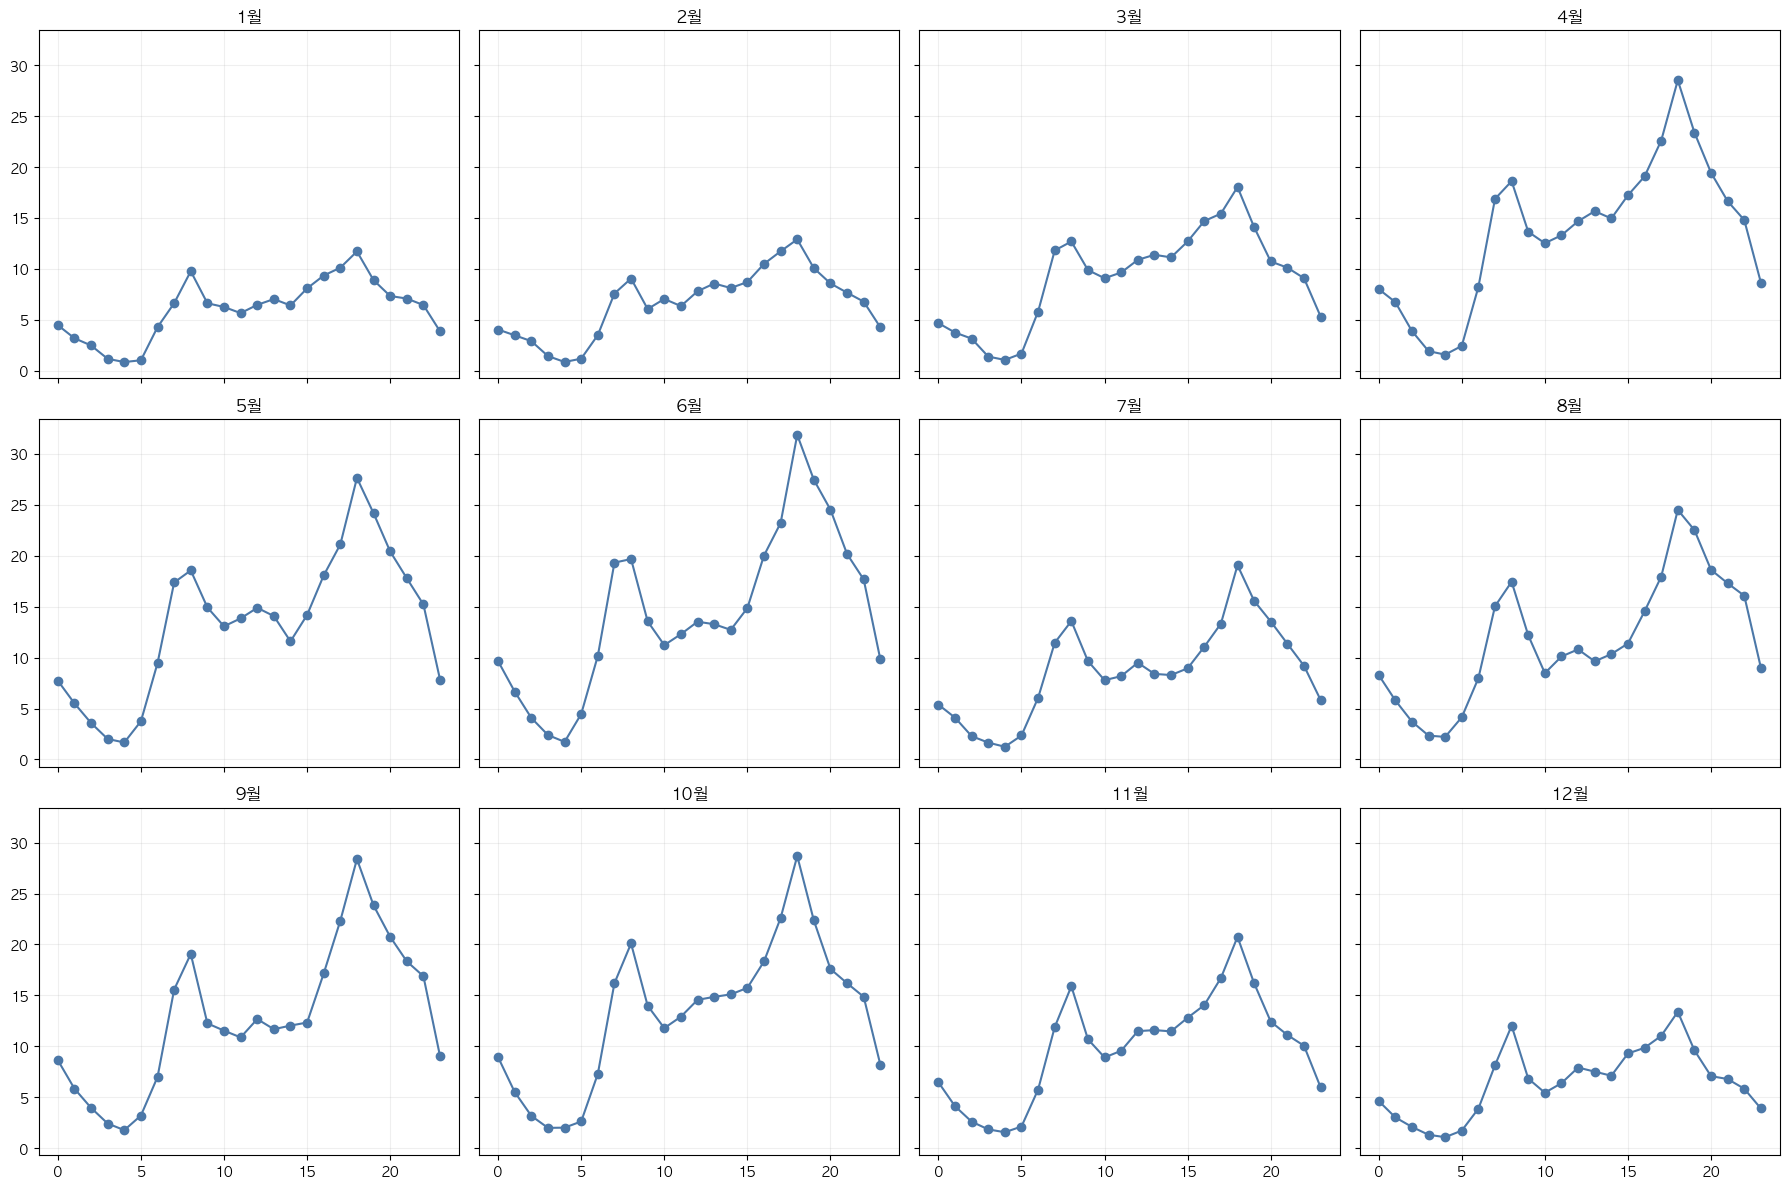

In [17]:
fig, axes = plt.subplots(3, 4, figsize=(18, 12), sharex=True, sharey=True)
axes = axes.flatten()

for idx, month in enumerate(monthly_hourly_pivot_2024.index):
    ax = axes[idx]
    ax.plot(
        monthly_hourly_pivot_2024.columns,
        monthly_hourly_pivot_2024.loc[month].values,
        marker='o',
        linewidth=1.5,
        color='#4C78A8'
    )
    ax.set_title(f'{month}월')
    ax.grid(alpha=0.2)

for ax in axes[len(monthly_hourly_pivot_2024.index):]:
    ax.axis('off')

plt.tight_layout()
plt.show()


## 월 간 유사도 계산

이 단계에서는 월별 시간대 패턴이 서로 얼마나 비슷한지 수치로 계산한다.

여기서는 두 가지 지표를 같이 본다.
- `상관계수`: 패턴의 모양이 얼마나 비슷한지
- `코사인 유사도`: 전체 방향성이 얼마나 비슷한지

이후 표를 보면 어떤 달끼리 비슷하고, 어떤 달끼리 차이가 큰지 확인할 수 있다.


In [18]:
monthly_corr_2024 = monthly_hourly_pivot_2024.T.corr()
monthly_cosine_2024 = pd.DataFrame(
    cosine_similarity(monthly_hourly_pivot_2024.fillna(0)),
    index=monthly_hourly_pivot_2024.index,
    columns=monthly_hourly_pivot_2024.index,
)

print('월별 패턴 상관계수')
display(monthly_corr_2024.round(4))

print('월별 패턴 코사인 유사도')
display(monthly_cosine_2024.round(4))


월별 패턴 상관계수


month,1,2,3,4,5,6,7,8,9,10,11,12
month,,,,,,,,,,,,
1,1.0000,0.9800,0.9798,0.9753,0.9498,0.9196,0.9464,0.9000,0.9331,0.9791,0.9866,0.9795
2,0.9800,1.0000,0.9881,0.9799,0.9418,0.9126,0.9304,0.8787,0.9265,0.9748,0.9794,0.9586
3,0.9798,0.9881,1.0000,0.9785,0.9475,0.9066,0.9343,0.8752,0.9112,0.9752,0.9845,0.9703
4,0.9753,0.9799,0.9785,1.0000,0.9838,0.9681,0.9791,0.9467,0.9701,0.9943,0.9883,0.9540
5,0.9498,0.9418,0.9475,0.9838,1.0000,0.9821,0.9913,0.9690,0.9797,0.9791,0.9655,0.9221
6,0.9196,0.9126,0.9066,0.9681,0.9821,1.0000,0.9845,0.9900,0.9910,0.9617,0.9382,0.8888
7,0.9464,0.9304,0.9343,0.9791,0.9913,0.9845,1.0000,0.9769,0.9835,0.9803,0.9677,0.9308
8,0.9000,0.8787,0.8752,0.9467,0.9690,0.9900,0.9769,1.0000,0.9884,0.9480,0.9205,0.8700
9,0.9331,0.9265,0.9112,0.9701,0.9797,0.9910,0.9835,0.9884,1.0000,0.9716,0.9483,0.9000


월별 패턴 코사인 유사도


month,1,2,3,4,5,6,7,8,9,10,11,12
month,,,,,,,,,,,,
1,1.0000,0.9962,0.9957,0.9946,0.9896,0.9823,0.9889,0.9800,0.9850,0.9950,0.9969,0.9956
2,0.9962,1.0000,0.9975,0.9957,0.9881,0.9810,0.9857,0.9756,0.9838,0.9944,0.9957,0.9916
3,0.9957,0.9975,1.0000,0.9955,0.9891,0.9796,0.9863,0.9742,0.9805,0.9947,0.9968,0.9939
4,0.9946,0.9957,0.9955,1.0000,0.9966,0.9929,0.9956,0.9889,0.9933,0.9988,0.9975,0.9904
5,0.9896,0.9881,0.9891,0.9966,1.0000,0.9959,0.9982,0.9935,0.9954,0.9955,0.9928,0.9838
6,0.9823,0.9810,0.9796,0.9929,0.9959,1.0000,0.9965,0.9976,0.9980,0.9915,0.9864,0.9758
7,0.9889,0.9857,0.9863,0.9956,0.9982,0.9965,1.0000,0.9952,0.9962,0.9958,0.9932,0.9855
8,0.9800,0.9756,0.9742,0.9889,0.9935,0.9976,0.9952,1.0000,0.9972,0.9889,0.9834,0.9731
9,0.9850,0.9838,0.9805,0.9933,0.9954,0.9980,0.9962,0.9972,1.0000,0.9936,0.9885,0.9781


## 비슷한 월 조합 정리

월별 유사도 표만 보면 한눈에 보기 어려울 수 있어서,
가장 비슷한 월 조합과 가장 덜 비슷한 월 조합을 따로 정리한다.


In [19]:
def make_month_pair_table(sim_df, value_name):
    rows = []
    months = list(sim_df.index)
    for i, month_a in enumerate(months):
        for month_b in months[i+1:]:
            rows.append({
                'month_a': month_a,
                'month_b': month_b,
                value_name: sim_df.loc[month_a, month_b],
            })
    return pd.DataFrame(rows).sort_values(value_name, ascending=False).reset_index(drop=True)

monthly_corr_pairs_2024 = make_month_pair_table(monthly_corr_2024, 'corr')
monthly_cosine_pairs_2024 = make_month_pair_table(monthly_cosine_2024, 'cosine_similarity')

print('상관계수 기준 가장 비슷한 월 Top 10')
display(monthly_corr_pairs_2024.head(10).round(4))

print('상관계수 기준 가장 덜 비슷한 월 Bottom 10')
display(monthly_corr_pairs_2024.tail(10).sort_values('corr').round(4))

print('코사인 유사도 기준 가장 비슷한 월 Top 10')
display(monthly_cosine_pairs_2024.head(10).round(4))


상관계수 기준 가장 비슷한 월 Top 10


,month_a,month_b,corr
0,10,11,0.9950
1,4,10,0.9943
2,5,7,0.9913
3,6,9,0.9910
4,6,8,0.9900
5,8,9,0.9884
6,4,11,0.9883
7,2,3,0.9881
8,1,11,0.9866
9,11,12,0.9849


상관계수 기준 가장 덜 비슷한 월 Bottom 10


,month_a,month_b,corr
65,8,12,0.8700
64,3,8,0.8752
63,2,8,0.8787
62,6,12,0.8888
61,1,8,0.9000
60,9,12,0.9000
59,3,6,0.9066
58,3,9,0.9112
57,2,6,0.9126
56,1,6,0.9196


코사인 유사도 기준 가장 비슷한 월 Top 10


,month_a,month_b,cosine_similarity
0,10,11,0.9989
1,4,10,0.9988
2,5,7,0.9982
3,6,9,0.9980
4,6,8,0.9976
5,4,11,0.9975
6,2,3,0.9975
7,8,9,0.9972
8,1,11,0.9969
9,11,12,0.9969


## 월별 패턴 군집화 준비

이 단계에서는 앞에서 만든 `monthly_hourly_pivot_2024`를 사용해 월별 패턴 군집화를 수행한다.

이번에는 군집 수를 하나로 고정하지 않고, `k=2`부터 `k=5`까지 각각 나누어 본다.
각 `k`마다 다음을 같이 확인한다.
- 월별 군집 라벨
- 실루엣 점수
- 같은 군집에 속한 월들의 패턴 그래프


In [20]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

cluster_results_by_k = {}
cluster_search_rows = []

for k in range(2, 6):
    model = AgglomerativeClustering(n_clusters=k)
    labels = model.fit_predict(monthly_hourly_pivot_2024.fillna(0).values)
    score = silhouette_score(monthly_hourly_pivot_2024.fillna(0).values, labels)

    month_cluster_df = pd.DataFrame({
        'month': monthly_hourly_pivot_2024.index,
        'cluster': labels,
    }).sort_values(['cluster', 'month']).reset_index(drop=True)

    cluster_results_by_k[k] = {
        'labels': labels,
        'month_cluster_df': month_cluster_df,
        'silhouette_score': score,
    }

    cluster_search_rows.append({
        'k': k,
        'silhouette_score': score,
    })

cluster_search_df = pd.DataFrame(cluster_search_rows).sort_values('k').reset_index(drop=True)
print('k=2~5 군집 탐색 결과')
display(cluster_search_df.round(4))


k=2~5 군집 탐색 결과


,k,silhouette_score
0,2,0.6204
1,3,0.5951
2,4,0.4388
3,5,0.4074


## 군집 수별 실루엣 점수 시각화

실루엣 점수는 군집이 얼마나 잘 분리되어 있는지 보는 지표다.
값이 상대적으로 높을수록 해당 군집 수가 더 자연스럽다고 해석할 수 있다.


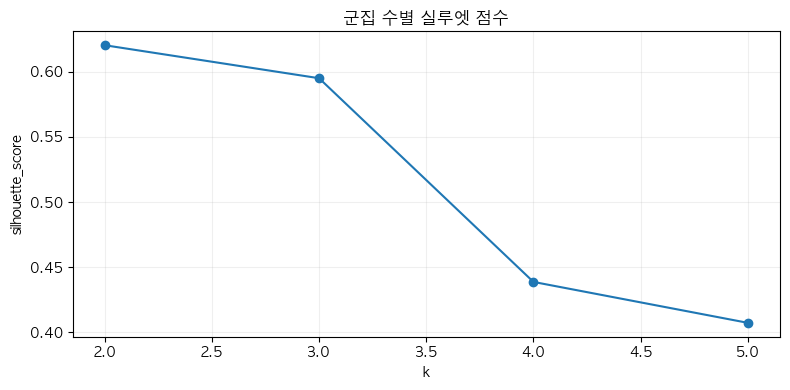

In [21]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(cluster_search_df['k'], cluster_search_df['silhouette_score'], marker='o', linewidth=1.5)
ax.set_title('군집 수별 실루엣 점수')
ax.set_xlabel('k')
ax.set_ylabel('silhouette_score')
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()


## k=2 군집 결과

아래 표는 `k=2`로 월별 패턴을 군집화했을 때 각 월이 어느 군집에 속하는지 보여준다.
그 아래 그래프는 같은 군집에 속한 월들을 한 축에 겹쳐 그려서, 패턴이 실제로 비슷한지 확인하는 용도다.


In [22]:
print('k=2 month-cluster table')
display(cluster_results_by_k[2]['month_cluster_df'])


k=2 month-cluster table


,month,cluster
0,1,0
1,2,0
2,3,0
3,7,0
4,11,0
5,12,0
6,4,1
7,5,1
8,6,1
9,8,1


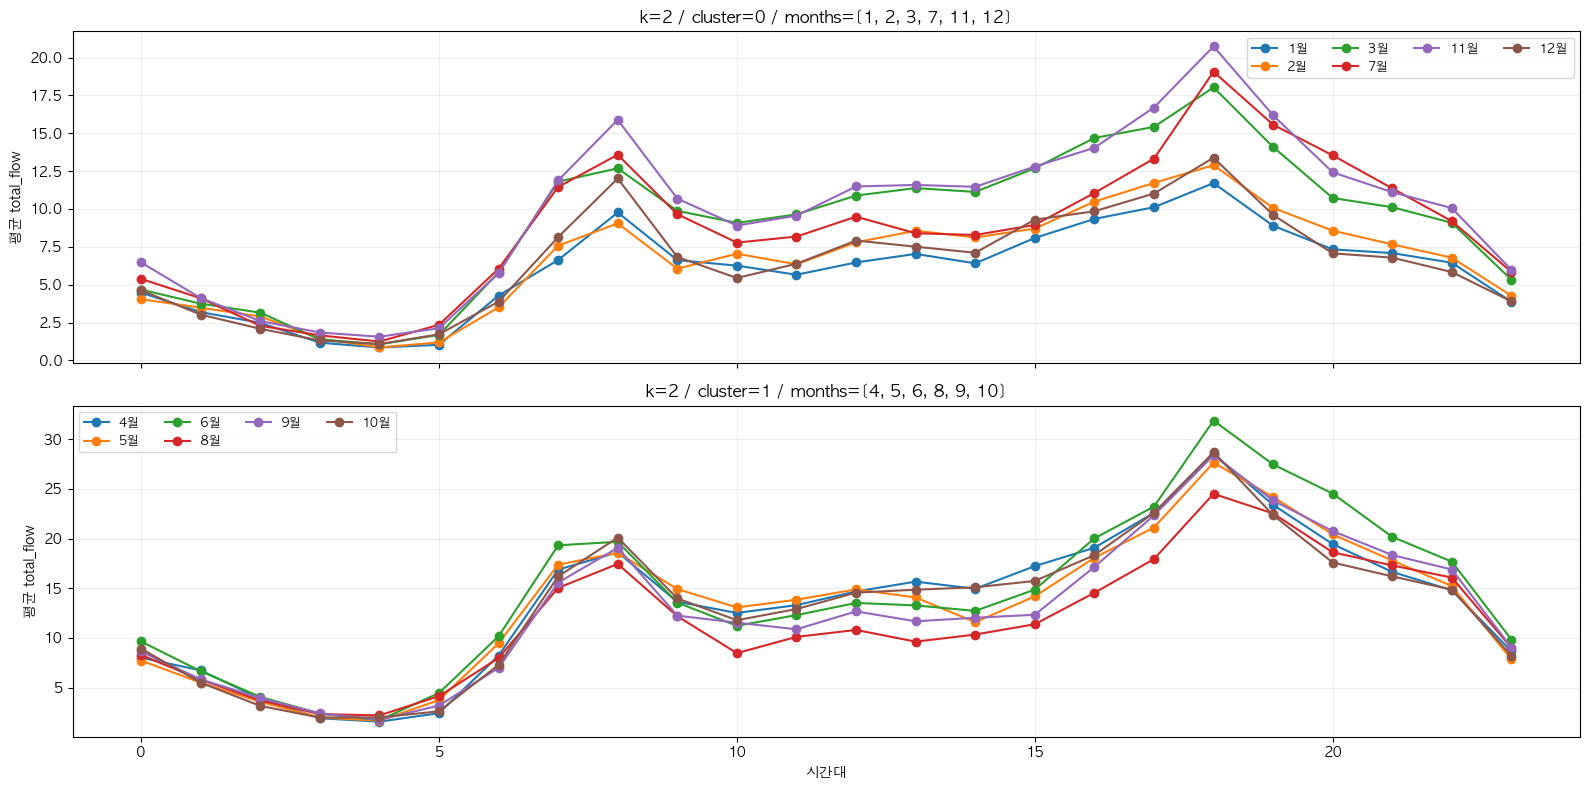

In [23]:
k = 2
month_cluster_df = cluster_results_by_k[k]['month_cluster_df']
cluster_ids = sorted(month_cluster_df['cluster'].unique())
fig, axes = plt.subplots(len(cluster_ids), 1, figsize=(16, 4 * len(cluster_ids)), sharex=True)
if len(cluster_ids) == 1:
    axes = [axes]

for ax, cluster_id in zip(axes, cluster_ids):
    cluster_months = month_cluster_df.loc[month_cluster_df['cluster'] == cluster_id, 'month'].tolist()
    for month in cluster_months:
        ax.plot(
            monthly_hourly_pivot_2024.columns,
            monthly_hourly_pivot_2024.loc[month].values,
            marker='o',
            linewidth=1.5,
            label=str(month) + '월'
        )
    ax.set_title('k=' + str(k) + ' / cluster=' + str(cluster_id) + ' / months=' + str(cluster_months))
    ax.set_ylabel('평균 total_flow')
    ax.grid(alpha=0.2)
    ax.legend(ncol=4, fontsize=9)

axes[-1].set_xlabel('시간대')
plt.tight_layout()
plt.show()


## k=3 군집 결과

아래 표는 `k=3`로 월별 패턴을 군집화했을 때 각 월이 어느 군집에 속하는지 보여준다.
그 아래 그래프는 같은 군집에 속한 월들을 한 축에 겹쳐 그려서, 패턴이 실제로 비슷한지 확인하는 용도다.


In [24]:
print('k=3 month-cluster table')
display(cluster_results_by_k[3]['month_cluster_df'])


k=3 month-cluster table


,month,cluster
0,4,0
1,5,0
2,6,0
3,8,0
4,9,0
5,10,0
6,3,1
7,7,1
8,11,1
9,1,2


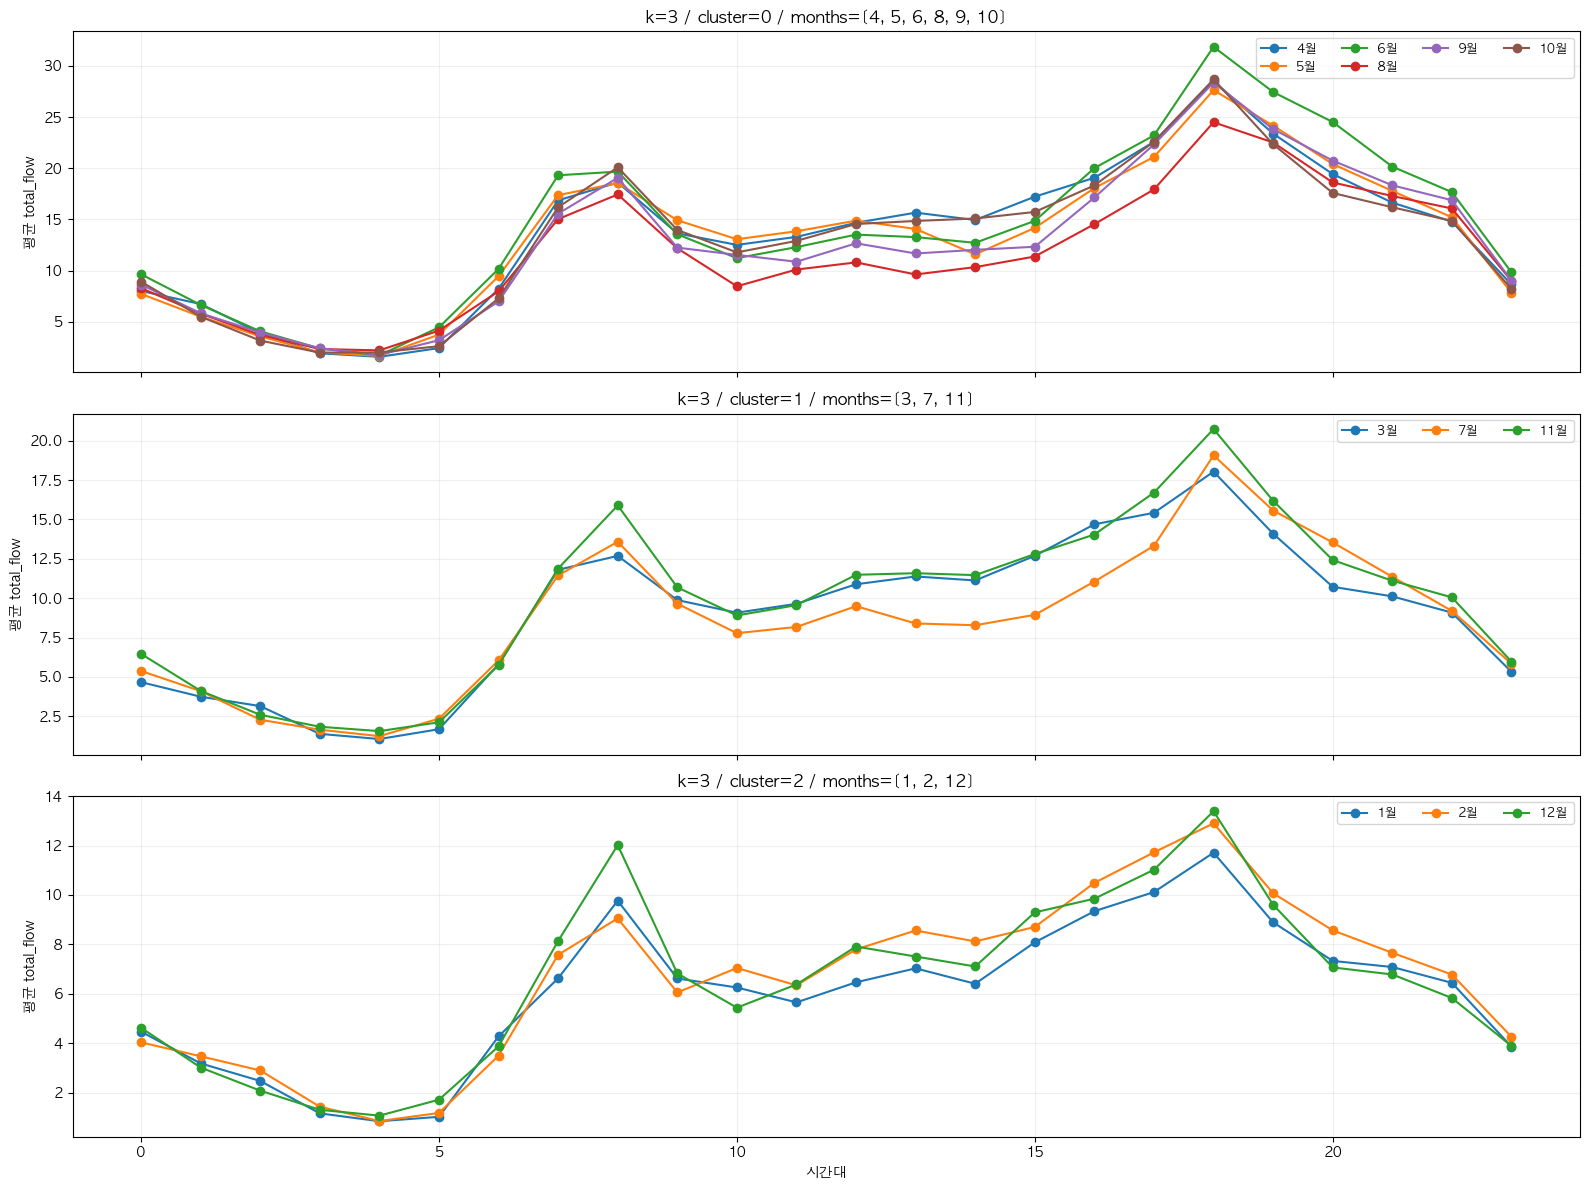

In [25]:
k = 3
month_cluster_df = cluster_results_by_k[k]['month_cluster_df']
cluster_ids = sorted(month_cluster_df['cluster'].unique())
fig, axes = plt.subplots(len(cluster_ids), 1, figsize=(16, 4 * len(cluster_ids)), sharex=True)
if len(cluster_ids) == 1:
    axes = [axes]

for ax, cluster_id in zip(axes, cluster_ids):
    cluster_months = month_cluster_df.loc[month_cluster_df['cluster'] == cluster_id, 'month'].tolist()
    for month in cluster_months:
        ax.plot(
            monthly_hourly_pivot_2024.columns,
            monthly_hourly_pivot_2024.loc[month].values,
            marker='o',
            linewidth=1.5,
            label=str(month) + '월'
        )
    ax.set_title('k=' + str(k) + ' / cluster=' + str(cluster_id) + ' / months=' + str(cluster_months))
    ax.set_ylabel('평균 total_flow')
    ax.grid(alpha=0.2)
    ax.legend(ncol=4, fontsize=9)

axes[-1].set_xlabel('시간대')
plt.tight_layout()
plt.show()


## k=4 군집 결과

아래 표는 `k=4`로 월별 패턴을 군집화했을 때 각 월이 어느 군집에 속하는지 보여준다.
그 아래 그래프는 같은 군집에 속한 월들을 한 축에 겹쳐 그려서, 패턴이 실제로 비슷한지 확인하는 용도다.


In [26]:
print('k=4 month-cluster table')
display(cluster_results_by_k[4]['month_cluster_df'])


k=4 month-cluster table


,month,cluster
0,4,0
1,5,0
2,6,0
3,9,0
4,10,0
5,3,1
6,7,1
7,11,1
8,1,2
9,2,2


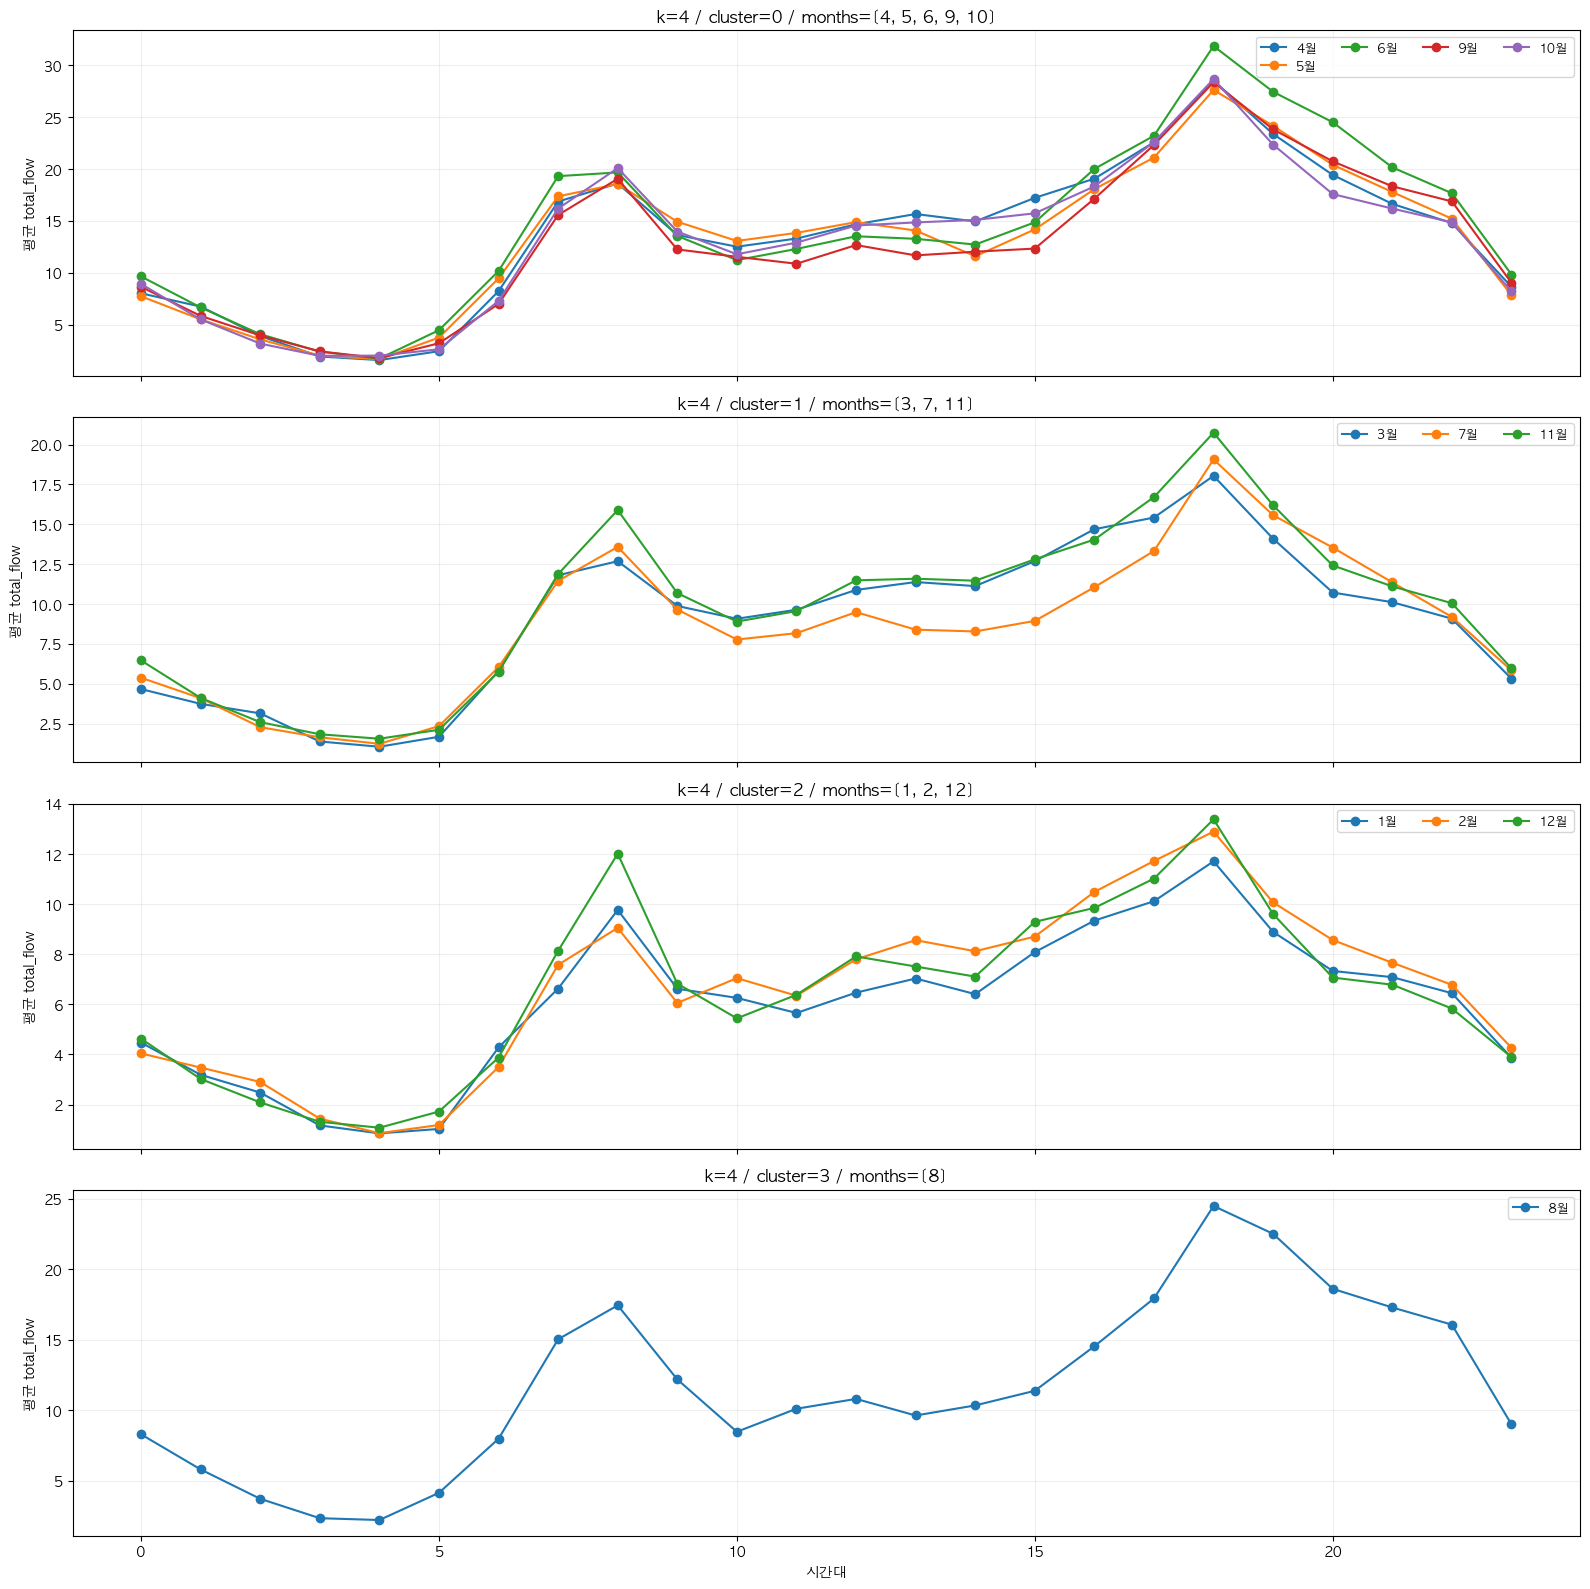

In [27]:
k = 4
month_cluster_df = cluster_results_by_k[k]['month_cluster_df']
cluster_ids = sorted(month_cluster_df['cluster'].unique())
fig, axes = plt.subplots(len(cluster_ids), 1, figsize=(16, 4 * len(cluster_ids)), sharex=True)
if len(cluster_ids) == 1:
    axes = [axes]

for ax, cluster_id in zip(axes, cluster_ids):
    cluster_months = month_cluster_df.loc[month_cluster_df['cluster'] == cluster_id, 'month'].tolist()
    for month in cluster_months:
        ax.plot(
            monthly_hourly_pivot_2024.columns,
            monthly_hourly_pivot_2024.loc[month].values,
            marker='o',
            linewidth=1.5,
            label=str(month) + '월'
        )
    ax.set_title('k=' + str(k) + ' / cluster=' + str(cluster_id) + ' / months=' + str(cluster_months))
    ax.set_ylabel('평균 total_flow')
    ax.grid(alpha=0.2)
    ax.legend(ncol=4, fontsize=9)

axes[-1].set_xlabel('시간대')
plt.tight_layout()
plt.show()


## k=5 군집 결과

아래 표는 `k=5`로 월별 패턴을 군집화했을 때 각 월이 어느 군집에 속하는지 보여준다.
그 아래 그래프는 같은 군집에 속한 월들을 한 축에 겹쳐 그려서, 패턴이 실제로 비슷한지 확인하는 용도다.


In [28]:
print('k=5 month-cluster table')
display(cluster_results_by_k[5]['month_cluster_df'])


k=5 month-cluster table


,month,cluster
0,3,0
1,7,0
2,11,0
3,4,1
4,5,1
5,9,1
6,10,1
7,1,2
8,2,2
9,12,2


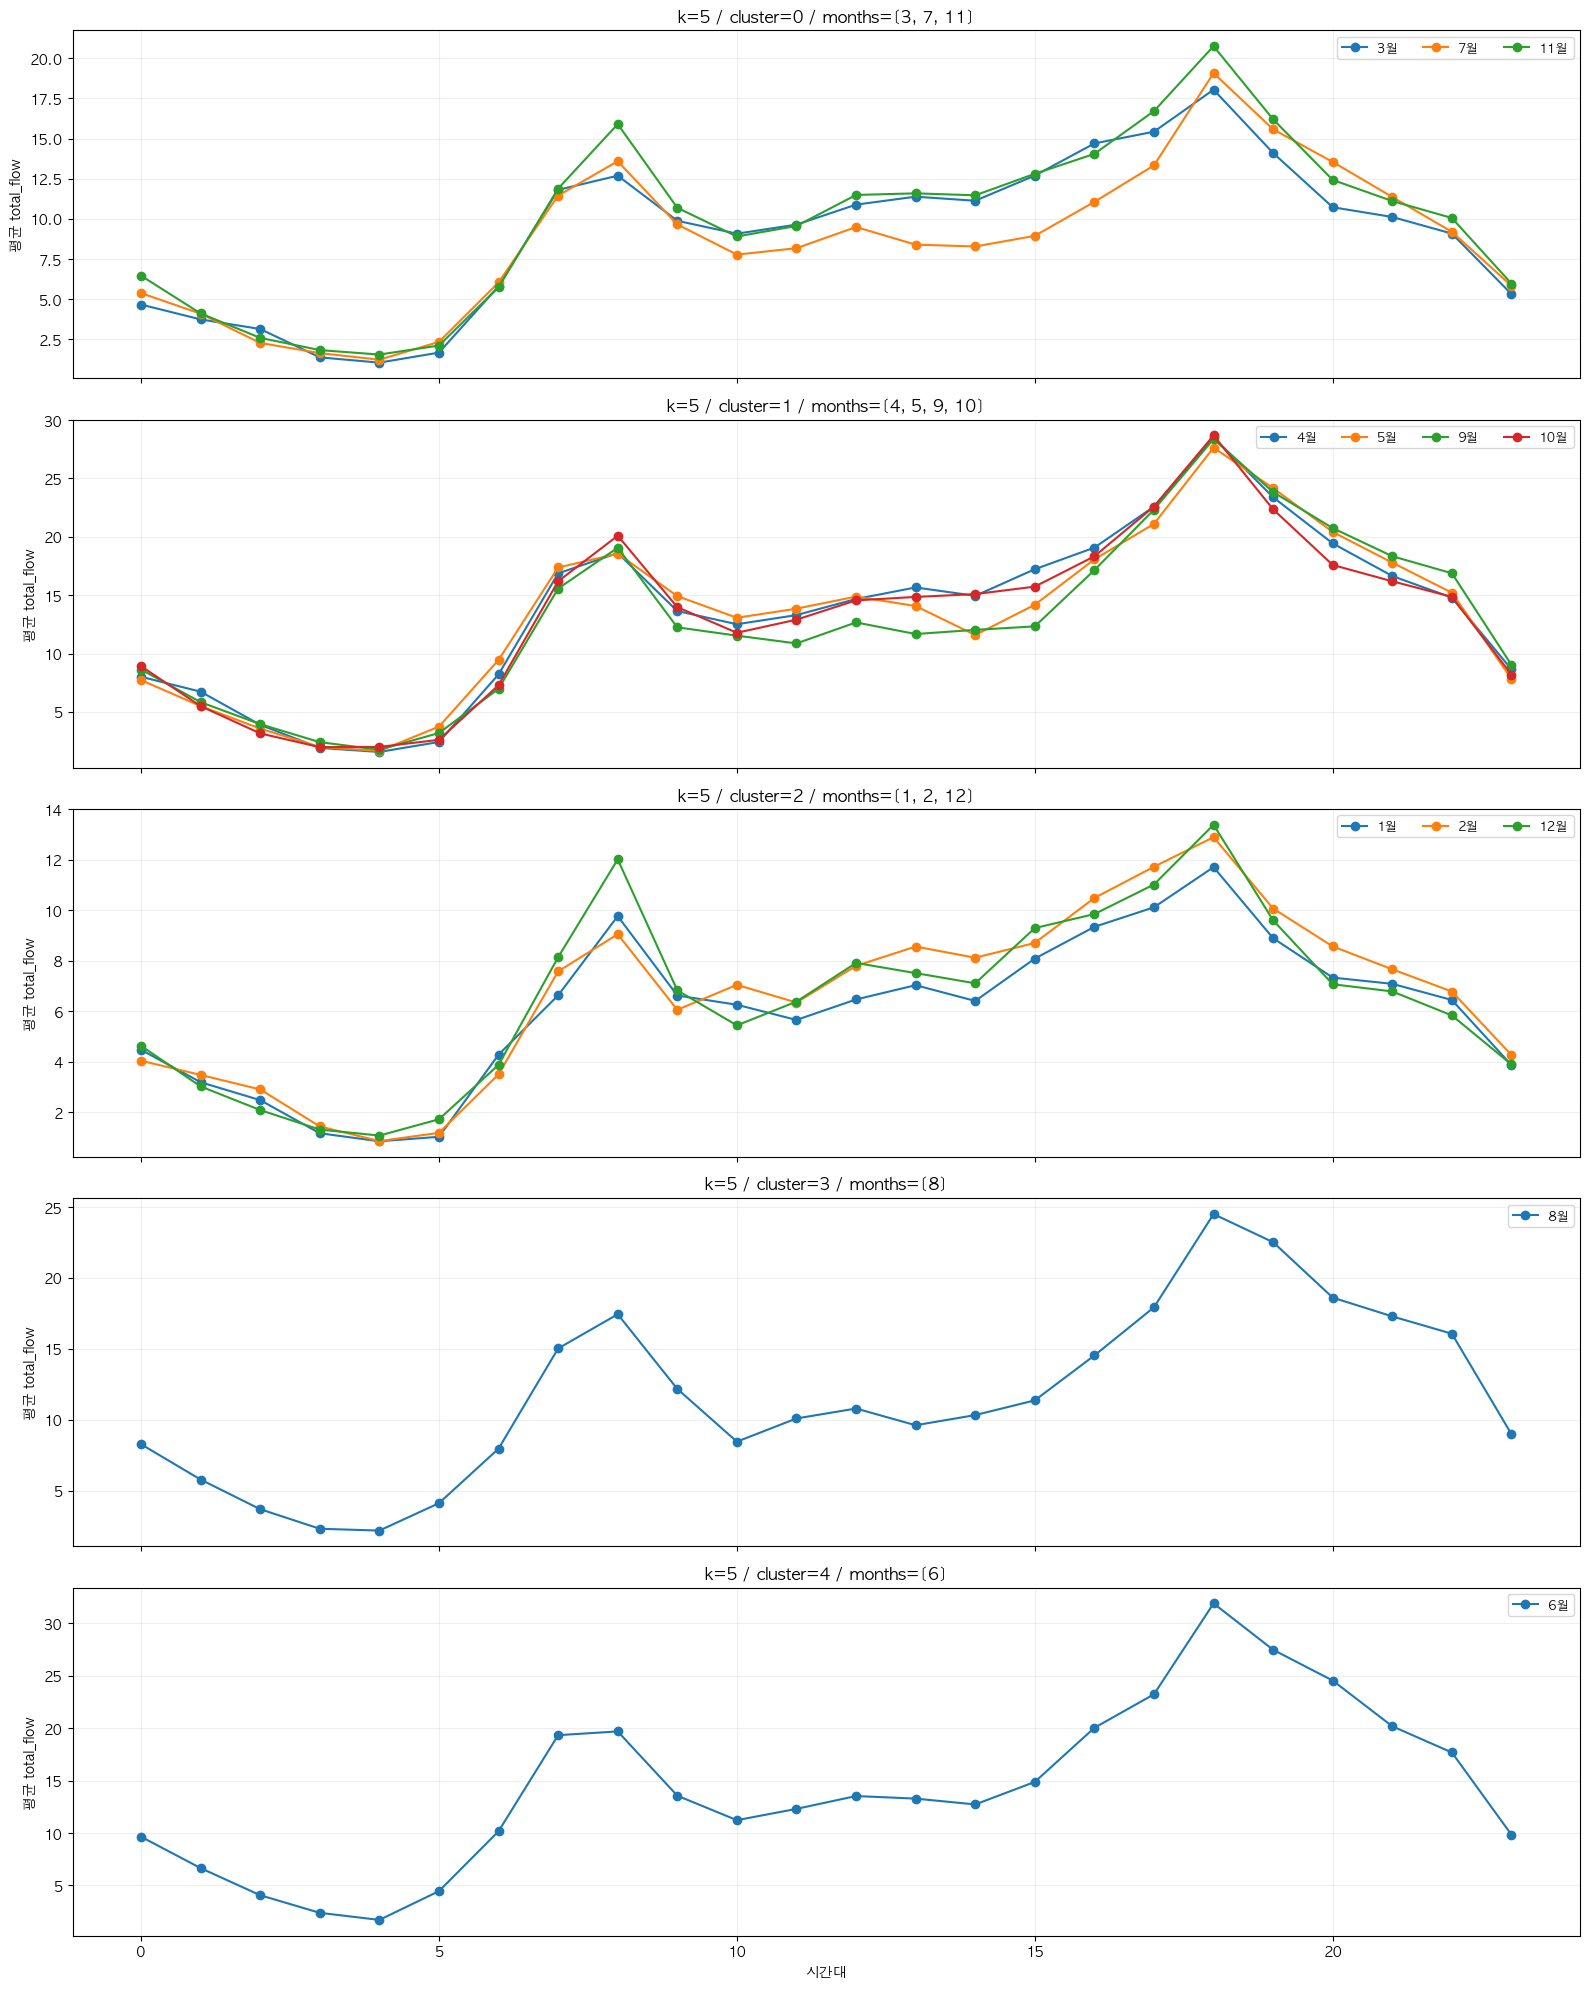

In [29]:
k = 5
month_cluster_df = cluster_results_by_k[k]['month_cluster_df']
cluster_ids = sorted(month_cluster_df['cluster'].unique())
fig, axes = plt.subplots(len(cluster_ids), 1, figsize=(16, 4 * len(cluster_ids)), sharex=True)
if len(cluster_ids) == 1:
    axes = [axes]

for ax, cluster_id in zip(axes, cluster_ids):
    cluster_months = month_cluster_df.loc[month_cluster_df['cluster'] == cluster_id, 'month'].tolist()
    for month in cluster_months:
        ax.plot(
            monthly_hourly_pivot_2024.columns,
            monthly_hourly_pivot_2024.loc[month].values,
            marker='o',
            linewidth=1.5,
            label=str(month) + '월'
        )
    ax.set_title('k=' + str(k) + ' / cluster=' + str(cluster_id) + ' / months=' + str(cluster_months))
    ax.set_ylabel('평균 total_flow')
    ax.grid(alpha=0.2)
    ax.legend(ncol=4, fontsize=9)

axes[-1].set_xlabel('시간대')
plt.tight_layout()
plt.show()


## 스테이션별 월별 패턴 생성

이제부터는 6개 스테이션을 한 번에 묶지 않고, 각 스테이션별로 월별 시간대 패턴을 만든다.

즉 월 선택 흐름은 다음과 같다.
- 스테이션별 `2024 hourly` 데이터 사용
- `month + 시간대` 기준 평균 `total_flow` 계산
- 스테이션별 월별 24시간 패턴 생성
- 각 스테이션 안에서 `k=2~5` 군집화
- 각 클러스터에서 대표 월 1개 선택

이후 학습은 각 스테이션의 대표 월 데이터만 모아서 통합 모델로 진행한다.


In [30]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, r2_score, mean_absolute_error, mean_squared_error
from sklearn.base import clone
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
import holidays

korea_holidays = holidays.country_holidays('KR', years=[2024, 2025])

station_monthly_usage_2024 = {}
station_monthly_pivot_2024 = {}
station_monthly_pair_summary = []

for station_id in station_ids:
    monthly_usage = (
        station_hourly_2024[station_id]
        .groupby(['month', '시간대'], as_index=False)[['inflow', 'outflow', 'total_flow', 'net_flow']]
        .mean()
        .sort_values(['month', '시간대'])
        .reset_index(drop=True)
    )
    monthly_pivot = (
        monthly_usage
        .pivot(index='month', columns='시간대', values='total_flow')
        .sort_index()
        .fillna(0)
    )
    station_monthly_usage_2024[station_id] = monthly_usage
    station_monthly_pivot_2024[station_id] = monthly_pivot
    station_monthly_pair_summary.append({
        'station_id': station_id,
        'station_name': station_info[station_id],
        'month_count': len(monthly_pivot),
        'hour_count': monthly_pivot.shape[1],
    })

station_monthly_pair_summary = pd.DataFrame(station_monthly_pair_summary)
display(station_monthly_pair_summary)


,station_id,station_name,month_count,hour_count
0,ST-481,상현,12,24
1,ST-2425,다원,12,24
2,ST-1331,찬솔,12,24
3,ST-454,신영,12,24
4,ST-453,혜전,12,24
5,ST-2264,광태,12,24


## 스테이션별 군집화와 대표 월 선택

각 스테이션에 대해 `k=2~5` 군집화를 각각 수행한다.
대표 월은 같은 클러스터 안에서 중심 패턴에 가장 가까운 월 1개를 선택한다.

즉 이제 대표 월은 `전체 6개 스테이션 공통`이 아니라,
`스테이션별로 따로 선택된 최적 월`이 된다.


In [31]:
def select_representative_months(monthly_hourly_pivot, k):
    model = AgglomerativeClustering(n_clusters=k)
    labels = model.fit_predict(monthly_hourly_pivot.values)
    month_cluster_df = pd.DataFrame({
        'month': monthly_hourly_pivot.index,
        'cluster': labels,
    }).sort_values(['cluster', 'month']).reset_index(drop=True)

    work = month_cluster_df.copy()
    work['distance_to_center'] = np.nan
    for cluster_id in sorted(work['cluster'].unique()):
        cluster_months = work.loc[work['cluster'] == cluster_id, 'month'].tolist()
        center = monthly_hourly_pivot.loc[cluster_months].mean(axis=0).values
        for month in cluster_months:
            vec = monthly_hourly_pivot.loc[month].values
            dist = float(np.linalg.norm(vec - center))
            work.loc[work['month'] == month, 'distance_to_center'] = dist

    representative_df = (
        work.sort_values(['cluster', 'distance_to_center', 'month'])
        .groupby('cluster', group_keys=False)
        .head(1)
        .sort_values(['cluster', 'month'])
        .reset_index(drop=True)
    )
    score = silhouette_score(monthly_hourly_pivot.values, labels)
    return work, representative_df, score

station_cluster_results = {}
station_cluster_summary_rows = []

for station_id in station_ids:
    station_cluster_results[station_id] = {}
    pivot = station_monthly_pivot_2024[station_id]
    for k in range(2, 6):
        month_cluster_df, representative_df, score = select_representative_months(pivot, k)
        station_cluster_results[station_id][k] = {
            'month_cluster_df': month_cluster_df,
            'representative_df': representative_df,
            'silhouette_score': score,
        }
        station_cluster_summary_rows.append({
            'station_id': station_id,
            'station_name': station_info[station_id],
            'k': k,
            'silhouette_score': score,
            'selected_months': ', '.join(map(str, representative_df['month'].tolist())),
            'month_count': len(representative_df),
        })

station_cluster_summary = pd.DataFrame(station_cluster_summary_rows).sort_values(['station_id', 'k']).reset_index(drop=True)
display(station_cluster_summary.round(4))


,station_id,station_name,k,silhouette_score,selected_months,month_count
0,ST-1331,찬솔,2,0.5319,"5, 12",2
1,ST-1331,찬솔,3,0.3466,"12, 11, 6",3
2,ST-1331,찬솔,4,0.3306,"11, 3, 6, 2",4
3,ST-1331,찬솔,5,0.3253,"6, 3, 4, 2, 8",5
4,ST-2264,광태,2,0.5902,"12, 10",2
5,ST-2264,광태,3,0.5314,"10, 11, 2",3
6,ST-2264,광태,4,0.3944,"9, 11, 2, 5",4
7,ST-2264,광태,5,0.3589,"11, 5, 2, 6, 8",5
8,ST-2425,다원,2,0.5722,"3, 9",2
9,ST-2425,다원,3,0.3911,"9, 1, 3",3


## 스테이션별 대표 월 확인

아래 표는 스테이션별로 `k=2~5`에서 어떤 월이 선택되었는지 보기 쉽게 정리한 표다.
이 표를 기준으로 각 스테이션이 어떤 계절 구간을 대표 월로 가져가는지 확인할 수 있다.


In [32]:
representative_month_pivot = station_cluster_summary.pivot_table(
    index=['station_id', 'station_name'],
    columns='k',
    values='selected_months',
    aggfunc='first'
).reset_index()
representative_month_pivot.columns = ['station_id', 'station_name', 'k2_selected_months', 'k3_selected_months', 'k4_selected_months', 'k5_selected_months']
display(representative_month_pivot)


,station_id,station_name,k2_selected_months,k3_selected_months,k4_selected_months,k5_selected_months
0,ST-1331,찬솔,"5, 12","12, 11, 6","11, 3, 6, 2","6, 3, 4, 2, 8"
1,ST-2264,광태,"12, 10","10, 11, 2","9, 11, 2, 5","11, 5, 2, 6, 8"
2,ST-2425,다원,"3, 9","9, 1, 3","9, 1, 3, 6","1, 4, 3, 6, 10"
3,ST-453,혜전,"8, 12","10, 12, 5","5, 11, 8, 12","8, 11, 4, 12, 6"
4,ST-454,신영,"7, 5","11, 5, 2","5, 3, 2, 8","2, 3, 5, 8, 10"
5,ST-481,상현,"3, 5","5, 7, 2","7, 6, 2, 9","6, 9, 2, 3, 11"


## 학습용 피처 엔지니어링

이 단계에서는 모델 학습에 사용할 시간대 데이터를 만든다.

사용 피처는 다음과 같다.
- 요일 원핫인코딩: `weekday_0 ~ weekday_6`
- 주말 원핫인코딩: `is_weekend`
- 공휴일 원핫인코딩: `holiday_flag`
- 날씨: `온도`, `습도`, `강수량`, `불쾌지수`, `snow_flag`
- 시간: `hour_sin`, `hour_cos`
- 스테이션 구분: `station_id` one-hot encoding

중요한 점은 `week_weight`를 피처로 넣지 않는다는 것이다.
이번에는 `week_weight`를 모델 입력값이 아니라 `sample_weight`로 사용한다.
즉 주차별 가중치는 학습 시 표본 가중치로만 반영한다.


In [33]:
def build_model_hourly_frame(df, station_id, week_weight_table):
    work = df.copy()
    if 'timestamp' in work.columns:
        work['timestamp'] = pd.to_datetime(work['timestamp'])
    else:
        work['기준_날짜'] = pd.to_datetime(work['기준_날짜'])
        if '시간대' in work.columns:
            work['timestamp'] = work['기준_날짜'] + pd.to_timedelta(work['시간대'], unit='h')
        else:
            work['timestamp'] = work['기준_날짜']

    feature_candidates = ['온도', '습도', '강수량', 'snow_flag']
    agg_map = {
        'inflow': ('station_role', lambda s: ((s == 'end') | (s == 'both')).sum()),
        'outflow': ('station_role', lambda s: ((s == 'start') | (s == 'both')).sum()),
    }
    for col in feature_candidates:
        if col in work.columns:
            agg_map[col] = (col, 'first')

    hourly = (
        work.sort_values('timestamp')
        .groupby('timestamp')
        .agg(**agg_map)
    )
    full_index = pd.date_range(hourly.index.min(), hourly.index.max(), freq='h')
    hourly = hourly.reindex(full_index)
    hourly.index.name = 'timestamp'
    hourly[['inflow', 'outflow']] = hourly[['inflow', 'outflow']].fillna(0)

    for col in feature_candidates:
        if col not in hourly.columns:
            hourly[col] = np.nan
        hourly[col] = hourly[col].ffill().bfill()

    hourly = hourly.reset_index()
    hourly['station_id'] = station_id
    hourly['total_flow'] = hourly['inflow'] + hourly['outflow']
    hourly['net_flow'] = hourly['inflow'] - hourly['outflow']
    iso = hourly['timestamp'].dt.isocalendar()
    hourly['연도'] = iso.year.astype(int)
    hourly['주차'] = iso.week.astype(int)
    hourly['연도_주차'] = hourly['연도'].astype(str) + '-' + hourly['주차'].astype(str).str.zfill(2)
    hourly['시간대'] = hourly['timestamp'].dt.hour
    hourly['hour_sin'] = np.sin(2 * np.pi * hourly['시간대'] / 24)
    hourly['hour_cos'] = np.cos(2 * np.pi * hourly['시간대'] / 24)
    hourly['month'] = hourly['timestamp'].dt.month
    hourly['weekday'] = hourly['timestamp'].dt.weekday
    hourly['is_weekend'] = (hourly['weekday'] >= 5).astype(int)
    hourly['holiday_flag'] = hourly['timestamp'].dt.date.map(lambda x: int(x in korea_holidays))
    hourly['불쾌지수'] = 0.81 * hourly['온도'] + 0.01 * hourly['습도'] * (0.99 * hourly['온도'] - 14.3) + 46.3
    for weekday_value in range(7):
        hourly[f'weekday_{weekday_value}'] = (hourly['weekday'] == weekday_value).astype(int)

    hourly = hourly.merge(
        week_weight_table[['연도_주차', 'week_weight', 'log_weight']],
        on='연도_주차',
        how='left'
    )
    hourly['week_weight'] = hourly['week_weight'].fillna(1.0)
    hourly['log_weight'] = hourly['log_weight'].fillna(0.0)
    hourly['sample_weight'] = hourly['week_weight'].clip(lower=0.3, upper=3.0)
    return hourly

station_model_2024 = {}
station_model_2025 = {}
model_frame_summary_rows = []

for station_id in station_ids:
    station_model_2024[station_id] = build_model_hourly_frame(
        station_week_2024[station_id],
        station_id,
        station_week_weight_2024[station_id],
    )
    station_model_2025[station_id] = build_model_hourly_frame(
        station_week_2025[station_id],
        station_id,
        station_week_weight_2025[station_id],
    )
    model_frame_summary_rows.append({
        'station_id': station_id,
        'station_name': station_info[station_id],
        'train_rows_2024': len(station_model_2024[station_id]),
        'test_rows_2025': len(station_model_2025[station_id]),
        'mean_sample_weight_2024': round(station_model_2024[station_id]['sample_weight'].mean(), 4),
        'min_sample_weight_2024': round(station_model_2024[station_id]['sample_weight'].min(), 4),
        'max_sample_weight_2024': round(station_model_2024[station_id]['sample_weight'].max(), 4),
    })

model_frame_summary = pd.DataFrame(model_frame_summary_rows)
display(model_frame_summary)


,station_id,station_name,train_rows_2024,test_rows_2025,mean_sample_weight_2024,min_sample_weight_2024,max_sample_weight_2024
0,ST-481,상현,8784,8567,1.0108,0.3,1.4677
1,ST-2425,다원,8782,8567,1.0112,0.3,1.6728
2,ST-1331,찬솔,8784,8568,1.0112,0.3,1.5410
3,ST-454,신영,8784,8568,1.0118,0.3,1.5835
4,ST-453,혜전,8783,8567,1.0122,0.3,1.6602
5,ST-2264,광태,8784,8568,1.0113,0.3,1.5373


## 모델 비교 설정

이번 비교는 `inflow`, `outflow` 두 타깃에 대해 진행한다.
`k=2~5` 각각에서 스테이션별 대표 월을 따로 선택한 뒤,
각 스테이션의 대표 월 데이터만 모아서 통합 모델을 학습한다.

즉 구조는 다음과 같다.
- 스테이션별 대표 월 선택
- 대표 월 내부 `7:3` 분리로 `train / valid`
- 스테이션별 데이터를 합쳐 통합 학습
- `2025` 전체 데이터로 테스트
- `sample_weight = week_weight`

통합 학습 시에는 `station_id`를 one-hot encoding으로 추가한다.


In [34]:
base_model_feature_cols = [
    'weekday_0', 'weekday_1', 'weekday_2', 'weekday_3', 'weekday_4', 'weekday_5', 'weekday_6',
    'is_weekend', 'holiday_flag', '온도', '습도', '강수량', '불쾌지수', 'snow_flag', 'hour_sin', 'hour_cos'
]
search_cv = TimeSeriesSplit(n_splits=3)
alpha_grid = np.logspace(-3, 2, 6)

model_space = {
    'LinearRegression': {
        'estimator': make_pipeline(SimpleImputer(strategy='median'), StandardScaler(), LinearRegression()),
        'search_type': 'none',
        'weight_param': 'linearregression__sample_weight',
    },
    'Ridge': {
        'estimator': make_pipeline(SimpleImputer(strategy='median'), StandardScaler(), Ridge()),
        'search_type': 'grid',
        'param_grid': {'ridge__alpha': alpha_grid},
        'weight_param': 'ridge__sample_weight',
    },
    'Lasso': {
        'estimator': make_pipeline(SimpleImputer(strategy='median'), StandardScaler(), Lasso(max_iter=20000)),
        'search_type': 'grid',
        'param_grid': {'lasso__alpha': alpha_grid},
        'weight_param': 'lasso__sample_weight',
    },
    'ElasticNet': {
        'estimator': make_pipeline(SimpleImputer(strategy='median'), StandardScaler(), ElasticNet(max_iter=20000)),
        'search_type': 'grid',
        'param_grid': {
            'elasticnet__alpha': alpha_grid,
            'elasticnet__l1_ratio': [0.2, 0.5, 0.8],
        },
        'weight_param': 'elasticnet__sample_weight',
    },
    'RandomForest': {
        'estimator': make_pipeline(SimpleImputer(strategy='median'), RandomForestRegressor(random_state=42, n_jobs=1)),
        'search_type': 'grid',
        'param_grid': {
            'randomforestregressor__n_estimators': [200, 300],
            'randomforestregressor__max_depth': [4, 8, None],
            'randomforestregressor__min_samples_leaf': [3, 5, 10],
        },
        'weight_param': 'randomforestregressor__sample_weight',
    },
    'HGB': {
        'estimator': make_pipeline(SimpleImputer(strategy='median'), HistGradientBoostingRegressor(random_state=42)),
        'search_type': 'grid',
        'param_grid': {
            'histgradientboostingregressor__max_depth': [3, 4, None],
            'histgradientboostingregressor__min_samples_leaf': [10, 20, 30],
            'histgradientboostingregressor__learning_rate': [0.03, 0.05, 0.1],
        },
        'weight_param': 'histgradientboostingregressor__sample_weight',
    },
}

def split_selected_months(hourly_df, selected_months, train_ratio=0.7):
    train_parts = []
    valid_parts = []
    for month in selected_months:
        month_df = hourly_df.loc[hourly_df['month'] == month].sort_values('timestamp').copy()
        if month_df.empty:
            continue
        if len(month_df) == 1:
            train_parts.append(month_df.copy())
            continue
        split_idx = int(len(month_df) * train_ratio)
        split_idx = min(max(split_idx, 1), len(month_df) - 1)
        train_parts.append(month_df.iloc[:split_idx].copy())
        valid_parts.append(month_df.iloc[split_idx:].copy())
    train_df = pd.concat(train_parts, ignore_index=True) if train_parts else hourly_df.iloc[0:0].copy()
    valid_df = pd.concat(valid_parts, ignore_index=True) if valid_parts else hourly_df.iloc[0:0].copy()
    return train_df, valid_df

def make_design_matrices(train_df, valid_df, test_df, feature_cols):
    train_base = train_df[feature_cols + ['station_id']].copy()
    valid_base = valid_df[feature_cols + ['station_id']].copy()
    test_base = test_df[feature_cols + ['station_id']].copy()
    X_train = pd.get_dummies(train_base, columns=['station_id'])
    X_valid = pd.get_dummies(valid_base, columns=['station_id']).reindex(columns=X_train.columns, fill_value=0)
    X_test = pd.get_dummies(test_base, columns=['station_id']).reindex(columns=X_train.columns, fill_value=0)
    return X_train, X_valid, X_test

def metric_dict(y_true, y_pred, prefix):
    return {
        f'{prefix}_R2': r2_score(y_true, y_pred),
        f'{prefix}_MAE': mean_absolute_error(y_true, y_pred),
        f'{prefix}_RMSE': mean_squared_error(y_true, y_pred) ** 0.5,
    }


## 스테이션별 대표 월 선택 기반 통합 학습

이 셀은 `k=2~5` 각각에 대해 아래 과정을 반복한다.
- 스테이션별 대표 월 선택
- 대표 월 내부를 `7:3`으로 `train / valid` 분리
- 6개 스테이션 데이터를 합쳐 통합 학습
- `sample_weight`로 `week_weight` 반영
- `2025` 전체 테스트 평가

즉 이제 주차별 가중치는 실제 학습 가중치로 사용된다.


In [35]:
model_compare_rows = []
split_summary_rows = []

for k in range(2, 6):
    combined_train_parts = []
    combined_valid_parts = []
    combined_test_parts = []

    for station_id in station_ids:
        selected_months = station_cluster_results[station_id][k]['representative_df']['month'].tolist()
        train_df, valid_df = split_selected_months(station_model_2024[station_id], selected_months, train_ratio=0.7)
        test_df = station_model_2025[station_id].copy()
        combined_train_parts.append(train_df)
        combined_valid_parts.append(valid_df)
        combined_test_parts.append(test_df)
        split_summary_rows.append({
            'k': k,
            'station_id': station_id,
            'station_name': station_info[station_id],
            'selected_months': ', '.join(map(str, selected_months)),
            'train_rows': len(train_df),
            'valid_rows': len(valid_df),
            'test_rows': len(test_df),
            'mean_train_weight': round(train_df['sample_weight'].mean(), 4) if len(train_df) else np.nan,
        })

    combined_train_df = pd.concat(combined_train_parts, ignore_index=True).sort_values('timestamp').reset_index(drop=True)
    combined_valid_df = pd.concat(combined_valid_parts, ignore_index=True).sort_values('timestamp').reset_index(drop=True)
    combined_test_df = pd.concat(combined_test_parts, ignore_index=True).sort_values('timestamp').reset_index(drop=True)

    X_train, X_valid, X_test = make_design_matrices(
        combined_train_df, combined_valid_df, combined_test_df, base_model_feature_cols
    )
    sample_weight_train = combined_train_df['sample_weight'].values

    for target_col in ['inflow', 'outflow']:
        y_train = combined_train_df[target_col]
        y_valid = combined_valid_df[target_col]
        y_test = combined_test_df[target_col]

        for model_name, model_spec in model_space.items():
            estimator = clone(model_spec['estimator'])
            fit_kwargs = {model_spec['weight_param']: sample_weight_train}

            if model_spec['search_type'] == 'grid':
                search = GridSearchCV(
                    estimator=estimator,
                    param_grid=model_spec['param_grid'],
                    scoring='r2',
                    cv=search_cv,
                    n_jobs=1,
                )
                search.fit(X_train, y_train, **fit_kwargs)
                model = search.best_estimator_
                best_params = search.best_params_
            else:
                model = estimator
                model.fit(X_train, y_train, **fit_kwargs)
                best_params = 'default'

            pred_train = model.predict(X_train)
            pred_valid = model.predict(X_valid)
            pred_test = model.predict(X_test)

            row = {
                'k': k,
                'target': target_col,
                'model': model_name,
                'best_params': str(best_params),
                'train_rows': len(X_train),
                'valid_rows': len(X_valid),
                'test_rows': len(X_test),
                'weight_mean_train': float(np.mean(sample_weight_train)),
            }
            row.update(metric_dict(y_train, pred_train, 'train'))
            row.update(metric_dict(y_valid, pred_valid, 'valid'))
            row.update(metric_dict(y_test, pred_test, 'test'))
            row['train_test_gap'] = row['train_R2'] - row['test_R2']
            row['valid_test_gap'] = row['valid_R2'] - row['test_R2']
            model_compare_rows.append(row)

model_compare_results = pd.DataFrame(model_compare_rows).sort_values(
    ['k', 'target', 'test_R2'], ascending=[True, True, False]
).reset_index(drop=True)
model_split_summary = pd.DataFrame(split_summary_rows)

print('모델 점수 전체 결과')
display(model_compare_results.round(4))
print('k별 / 스테이션별 split 요약')
display(model_split_summary)


모델 점수 전체 결과


,k,target,model,best_params,train_rows,valid_rows,test_rows,weight_mean_train,train_R2,train_MAE,train_RMSE,valid_R2,valid_MAE,valid_RMSE,test_R2,test_MAE,test_RMSE,train_test_gap,valid_test_gap
0,2,inflow,HGB,{'histgradientboostingregressor__learning_rate...,6223,2681,51405,0.9597,0.6157,2.5015,3.4775,0.5500,2.7649,3.7767,0.5165,3.0565,4.4164,0.0992,0.0335
1,2,inflow,RandomForest,"{'randomforestregressor__max_depth': None, 'ra...",6223,2681,51405,0.9597,0.7992,1.7372,2.5140,0.5530,2.6439,3.7642,0.4978,3.0719,4.5011,0.3013,0.0552
2,2,inflow,Lasso,{'lasso__alpha': np.float64(0.1)},6223,2681,51405,0.9597,0.3010,3.3584,4.6902,0.2880,3.4618,4.7508,0.3096,3.6089,5.2778,-0.0086,-0.0216
3,2,inflow,Ridge,{'ridge__alpha': np.float64(1.0)},6223,2681,51405,0.9597,0.3104,3.3439,4.6584,0.3009,3.4370,4.7076,0.3090,3.6233,5.2799,0.0014,-0.0081
4,2,inflow,LinearRegression,default,6223,2681,51405,0.9597,0.3105,3.3438,4.6582,0.3010,3.4368,4.7072,0.3086,3.6251,5.2815,0.0019,-0.0076
5,2,inflow,ElasticNet,"{'elasticnet__alpha': np.float64(1.0), 'elasti...",6223,2681,51405,0.9597,0.2366,3.5919,4.9014,0.2248,3.6602,4.9573,0.2289,3.9021,5.5776,0.0077,-0.0041
6,2,outflow,HGB,{'histgradientboostingregressor__learning_rate...,6223,2681,51405,0.9597,0.7180,2.2243,3.0406,0.5848,2.6651,3.7164,0.5033,2.6830,3.7191,0.2147,0.0815
7,2,outflow,RandomForest,"{'randomforestregressor__max_depth': None, 'ra...",6223,2681,51405,0.9597,0.7929,1.8154,2.6059,0.5649,2.7171,3.8045,0.4412,2.8329,3.9448,0.3517,0.1237
8,2,outflow,Ridge,{'ridge__alpha': np.float64(0.001)},6223,2681,51405,0.9597,0.2704,3.5394,4.8910,0.2714,3.6299,4.9228,0.2034,3.4637,4.7099,0.0671,0.0681
9,2,outflow,LinearRegression,default,6223,2681,51405,0.9597,0.2704,3.5394,4.8910,0.2714,3.6299,4.9228,0.2034,3.4637,4.7099,0.0671,0.0681


k별 / 스테이션별 split 요약


,k,station_id,station_name,selected_months,train_rows,valid_rows,test_rows,mean_train_weight
0,2,ST-481,상현,"3, 5",1040,448,8567,1.0028
1,2,ST-2425,다원,"3, 9",1023,441,8567,1.0118
2,2,ST-1331,찬솔,"5, 12",1040,448,8568,0.9303
3,2,ST-454,신영,"7, 5",1040,448,8568,0.9779
4,2,ST-453,혜전,"8, 12",1040,448,8567,0.8463
5,2,ST-2264,광태,"12, 10",1040,448,8568,0.9901
6,3,ST-481,상현,"5, 7, 2",1527,657,8567,0.8628
7,3,ST-2425,다원,"9, 1, 3",1543,664,8567,0.8550
8,3,ST-1331,찬솔,"12, 11, 6",1526,658,8568,1.0806
9,3,ST-454,신영,"11, 5, 2",1510,650,8568,1.0268


## 결과 요약

아래 표는 각 `k`와 타깃별로 테스트 성능이 가장 높은 모델만 모은 것이다.
즉 스테이션별 대표 월 선택과 주차별 가중치 반영을 적용한 뒤,
어떤 군집 수와 어떤 모델 조합이 가장 좋은지 빠르게 볼 수 있다.


In [36]:
best_model_by_group = (
    model_compare_results
    .sort_values(['k', 'target', 'test_R2'], ascending=[True, True, False])
    .groupby(['k', 'target'], as_index=False)
    .head(3)
    .reset_index(drop=True)
)

print('k / target별 상위 모델 Top 3')
display(best_model_by_group.round(4))

pivot_test_r2 = model_compare_results.pivot_table(
    index=['k', 'target'],
    columns='model',
    values='test_R2'
)
print('테스트 R2 비교 피벗표')
display(pivot_test_r2.round(4))


k / target별 상위 모델 Top 3


,k,target,model,best_params,train_rows,valid_rows,test_rows,weight_mean_train,train_R2,train_MAE,train_RMSE,valid_R2,valid_MAE,valid_RMSE,test_R2,test_MAE,test_RMSE,train_test_gap,valid_test_gap
0,2,inflow,HGB,{'histgradientboostingregressor__learning_rate...,6223,2681,51405,0.9597,0.6157,2.5015,3.4775,0.5500,2.7649,3.7767,0.5165,3.0565,4.4164,0.0992,0.0335
1,2,inflow,RandomForest,"{'randomforestregressor__max_depth': None, 'ra...",6223,2681,51405,0.9597,0.7992,1.7372,2.5140,0.5530,2.6439,3.7642,0.4978,3.0719,4.5011,0.3013,0.0552
2,2,inflow,Lasso,{'lasso__alpha': np.float64(0.1)},6223,2681,51405,0.9597,0.3010,3.3584,4.6902,0.2880,3.4618,4.7508,0.3096,3.6089,5.2778,-0.0086,-0.0216
3,2,outflow,HGB,{'histgradientboostingregressor__learning_rate...,6223,2681,51405,0.9597,0.7180,2.2243,3.0406,0.5848,2.6651,3.7164,0.5033,2.6830,3.7191,0.2147,0.0815
4,2,outflow,RandomForest,"{'randomforestregressor__max_depth': None, 'ra...",6223,2681,51405,0.9597,0.7929,1.8154,2.6059,0.5649,2.7171,3.8045,0.4412,2.8329,3.9448,0.3517,0.1237
5,2,outflow,Ridge,{'ridge__alpha': np.float64(0.001)},6223,2681,51405,0.9597,0.2704,3.5394,4.8910,0.2714,3.6299,4.9228,0.2034,3.4637,4.7099,0.0671,0.0681
6,3,inflow,HGB,{'histgradientboostingregressor__learning_rate...,9176,3951,51405,0.9758,0.7598,2.0478,2.8446,0.6306,2.3826,3.2842,0.5981,2.7842,4.0267,0.1618,0.0325
7,3,inflow,RandomForest,"{'randomforestregressor__max_depth': None, 'ra...",9176,3951,51405,0.9758,0.8656,1.4634,2.1283,0.5987,2.4743,3.4229,0.5856,2.8442,4.0886,0.2799,0.0131
8,3,inflow,ElasticNet,"{'elasticnet__alpha': np.float64(0.1), 'elasti...",9176,3951,51405,0.9758,0.3365,3.4170,4.7283,0.3077,3.3588,4.4958,0.3107,3.7076,5.2733,0.0258,-0.0030
9,3,outflow,HGB,{'histgradientboostingregressor__learning_rate...,9176,3951,51405,0.9758,0.7576,2.1215,2.9046,0.6094,2.5084,3.4767,0.5140,2.6690,3.6788,0.2436,0.0954


테스트 R2 비교 피벗표


model      ElasticNet     HGB   Lasso  LinearRegression  RandomForest   Ridge
k target                                                                     
2 inflow       0.2289  0.5165  0.3096            0.3086        0.4978  0.3090
  outflow      0.1759  0.5033  0.0958            0.2034        0.4412  0.2034
3 inflow       0.3107  0.5981  0.3071            0.3039        0.5856  0.3062
  outflow      0.2004  0.5140  0.1880            0.1893        0.4522  0.1883
4 inflow       0.3010  0.5791  0.3011            0.3011        0.5899  0.3011
  outflow      0.2115  0.5477  0.1936            0.1938        0.5052  0.1938
5 inflow       0.3042  0.5984  0.3031            0.3031        0.5755  0.3031
  outflow      0.1920  0.5184  0.1765            0.1766        0.4862  0.1766

## 군집 수별 보기 편한 결과 표

전체 표가 길기 때문에, 아래에서는 `k=2~5`를 각각 나누어 본다.
각 군집 수마다 `inflow`, `outflow` 결과를 따로 보고,
`R²`, `MAE`, `RMSE`, gap를 색상으로 강조해서 보기 쉽게 정리한다.


In [37]:
def style_result_table(df):
    cols = [
        'model', 'best_params',
        'train_R2', 'valid_R2', 'test_R2',
        'train_MAE', 'valid_MAE', 'test_MAE',
        'train_RMSE', 'valid_RMSE', 'test_RMSE',
        'train_test_gap', 'valid_test_gap',
        'weight_mean_train'
    ]
    show_cols = [c for c in cols if c in df.columns]
    return (
        df[show_cols]
        .round(4)
        .style
        .background_gradient(subset=[c for c in ['train_R2', 'valid_R2', 'test_R2'] if c in df.columns], cmap='YlGn')
        .background_gradient(subset=[c for c in ['train_MAE', 'valid_MAE', 'test_MAE', 'train_RMSE', 'valid_RMSE', 'test_RMSE'] if c in df.columns], cmap='YlOrRd_r')
        .background_gradient(subset=[c for c in ['train_test_gap', 'valid_test_gap'] if c in df.columns], cmap='Blues_r')
    )

for k in range(2, 6):
    print('=' * 80)
    print(f'k={k} 결과 요약')
    print('=' * 80)

    k_split = model_split_summary[model_split_summary['k'] == k].copy()
    print('스테이션별 대표 월 및 split 요약')
    display(k_split)

    for target_col, target_name in [('inflow', '유입량'), ('outflow', '유출량')]:
        target_df = (
            model_compare_results[
                (model_compare_results['k'] == k) & (model_compare_results['target'] == target_col)
            ]
            .sort_values('test_R2', ascending=False)
            .reset_index(drop=True)
        )
        print(f'{target_name} 모델 결과')
        display(style_result_table(target_df))


k=2 결과 요약
스테이션별 대표 월 및 split 요약


,k,station_id,station_name,selected_months,train_rows,valid_rows,test_rows,mean_train_weight
0,2,ST-481,상현,"3, 5",1040,448,8567,1.0028
1,2,ST-2425,다원,"3, 9",1023,441,8567,1.0118
2,2,ST-1331,찬솔,"5, 12",1040,448,8568,0.9303
3,2,ST-454,신영,"7, 5",1040,448,8568,0.9779
4,2,ST-453,혜전,"8, 12",1040,448,8567,0.8463
5,2,ST-2264,광태,"12, 10",1040,448,8568,0.9901


유입량 모델 결과


,model,best_params,train_R2,valid_R2,test_R2,train_MAE,valid_MAE,test_MAE,train_RMSE,valid_RMSE,test_RMSE,train_test_gap,valid_test_gap,weight_mean_train
0,HGB,"{'histgradientboostingregressor__learning_rate': 0.1, 'histgradientboostingregressor__max_depth': 3, 'histgradientboostingregressor__min_samples_leaf': 10}",0.615700,0.550000,0.516500,2.501500,2.764900,3.056500,3.477500,3.776700,4.416400,0.099200,0.033500,0.959700
1,RandomForest,"{'randomforestregressor__max_depth': None, 'randomforestregressor__min_samples_leaf': 5, 'randomforestregressor__n_estimators': 300}",0.799200,0.553000,0.497800,1.737200,2.643900,3.071900,2.514000,3.764200,4.501100,0.301300,0.055200,0.959700
2,Lasso,{'lasso__alpha': np.float64(0.1)},0.301000,0.288000,0.309600,3.358400,3.461800,3.608900,4.690200,4.750800,5.277800,-0.008600,-0.021600,0.959700
3,Ridge,{'ridge__alpha': np.float64(1.0)},0.310400,0.300900,0.309000,3.343900,3.437000,3.623300,4.658400,4.707600,5.279900,0.001400,-0.008100,0.959700
4,LinearRegression,default,0.310500,0.301000,0.308600,3.343800,3.436800,3.625100,4.658200,4.707200,5.281500,0.001900,-0.007600,0.959700
5,ElasticNet,"{'elasticnet__alpha': np.float64(1.0), 'elasticnet__l1_ratio': 0.2}",0.236600,0.224800,0.228900,3.591900,3.660200,3.902100,4.901400,4.957300,5.577600,0.007700,-0.004100,0.959700


유출량 모델 결과


...

,k,station_id,station_name,selected_months,train_rows,valid_rows,test_rows,mean_train_weight
18,5,ST-481,상현,"6, 9, 2, 3, 11",2516,1084,8567,1.0444
19,5,ST-2425,다원,"1, 4, 3, 6, 10",2566,1105,8567,1.0751
20,5,ST-1331,찬솔,"6, 3, 4, 2, 8",2533,1091,8568,1.0235
21,5,ST-454,신영,"2, 3, 5, 8, 10",2567,1105,8568,1.0530
22,5,ST-453,혜전,"8, 11, 4, 12, 6",2549,1099,8567,1.1158
23,5,ST-2264,광태,"11, 5, 2, 6, 8",2533,1091,8568,1.0901


유입량 모델 결과


,model,best_params,train_R2,valid_R2,test_R2,train_MAE,valid_MAE,test_MAE,train_RMSE,valid_RMSE,test_RMSE,train_test_gap,valid_test_gap,weight_mean_train
0,HGB,"{'histgradientboostingregressor__learning_rate': 0.1, 'histgradientboostingregressor__max_depth': None, 'histgradientboostingregressor__min_samples_leaf': 20}",0.722100,0.646900,0.598400,2.274400,2.537800,2.784200,3.104600,3.531000,4.025400,0.123700,0.048500,1.067100
1,RandomForest,"{'randomforestregressor__max_depth': None, 'randomforestregressor__min_samples_leaf': 5, 'randomforestregressor__n_estimators': 300}",0.805300,0.633100,0.575500,1.837500,2.586600,2.860700,2.598600,3.599500,4.138400,0.229800,0.057600,1.067100
2,ElasticNet,"{'elasticnet__alpha': np.float64(0.1), 'elasticnet__l1_ratio': 0.2}",0.318500,0.338200,0.304200,3.531200,3.539600,3.700500,4.861400,4.834100,5.298300,0.014300,0.034000,1.067100
3,Lasso,{'lasso__alpha': np.float64(0.001)},0.320400,0.337200,0.303100,3.532200,3.551300,3.715400,4.854500,4.837500,5.302300,0.017300,0.034100,1.067100
4,LinearRegression,default,0.320500,0.337100,0.303100,3.532100,3.551800,3.715100,4.854400,4.838000,5.302500,0.017400,0.034000,1.067100
5,Ridge,{'ridge__alpha': np.float64(0.001)},0.320500,0.337100,0.303100,3.532100,3.551800,3.715100,4.854400,4.838000,5.302500,0.017400,0.034000,1.067100


유출량 모델 결과


,model,best_params,train_R2,valid_R2,test_R2,train_MAE,valid_MAE,test_MAE,train_RMSE,valid_RMSE,test_RMSE,train_test_gap,valid_test_gap,weight_mean_train
0,HGB,"{'histgradientboostingregressor__learning_rate': 0.1, 'histgradientboostingregressor__max_depth': None, 'histgradientboostingregressor__min_samples_leaf': 20}",0.722500,0.659700,0.518400,2.343500,2.655700,2.653900,3.189600,3.632000,3.661900,0.204100,0.141300,1.067100
1,RandomForest,"{'randomforestregressor__max_depth': None, 'randomforestregressor__min_samples_leaf': 5, 'randomforestregressor__n_estimators': 300}",0.810000,0.644500,0.486200,1.877500,2.696700,2.727100,2.639100,3.712700,3.782600,0.323900,0.158300,1.067100
2,ElasticNet,"{'elasticnet__alpha': np.float64(0.1), 'elasticnet__l1_ratio': 0.2}",0.290100,0.310000,0.192000,3.753600,3.771900,3.563100,5.101700,5.172300,4.743500,0.098200,0.118000,1.067100
3,LinearRegression,default,0.291400,0.309800,0.176600,3.750600,3.780200,3.592100,5.097100,5.172900,4.788300,0.114800,0.133200,1.067100
4,Ridge,{'ridge__alpha': np.float64(0.001)},0.291400,0.309800,0.176600,3.750600,3.780200,3.592100,5.097100,5.172900,4.788300,0.114800,0.133200,1.067100
5,Lasso,{'lasso__alpha': np.float64(0.001)},0.291300,0.309900,0.176500,3.750800,3.779800,3.593100,5.097200,5.172500,4.788700,0.114900,0.133400,1.067100


## 최종 사용 컬럼 확인

아래 셀은 현재 모델 학습에 실제로 사용한 컬럼을 확인하기 위한 셀이다.
- 기본 피처 컬럼
- `station_id` one-hot 전개 후 최종 입력 컬럼
를 같이 보여준다.


In [38]:
print('기본 피처 컬럼')
print(base_model_feature_cols)

sample_k = 2
sample_station_id = station_ids[0]
sample_months = station_cluster_results[sample_station_id][sample_k]['representative_df']['month'].tolist()

sample_train_parts = []
sample_valid_parts = []
sample_test_parts = []
for station_id in station_ids:
    train_df, valid_df = split_selected_months(station_model_2024[station_id], station_cluster_results[station_id][sample_k]['representative_df']['month'].tolist(), train_ratio=0.7)
    test_df = station_model_2025[station_id].copy()
    sample_train_parts.append(train_df)
    sample_valid_parts.append(valid_df)
    sample_test_parts.append(test_df)

sample_train_df = pd.concat(sample_train_parts, ignore_index=True)
sample_valid_df = pd.concat(sample_valid_parts, ignore_index=True)
sample_test_df = pd.concat(sample_test_parts, ignore_index=True)

X_train_sample, X_valid_sample, X_test_sample = make_design_matrices(
    sample_train_df, sample_valid_df, sample_test_df, base_model_feature_cols
)

final_feature_columns = pd.DataFrame({
    'final_feature_columns': X_train_sample.columns
})

print('one-hot 포함 최종 입력 컬럼 수:', len(X_train_sample.columns))
display(final_feature_columns)


기본 피처 컬럼
['weekday_0', 'weekday_1', 'weekday_2', 'weekday_3', 'weekday_4', 'weekday_5', 'weekday_6', 'is_weekend', 'holiday_flag', '온도', '습도', '강수량', '불쾌지수', 'snow_flag', 'hour_sin', 'hour_cos']
one-hot 포함 최종 입력 컬럼 수: 22


,final_feature_columns
0,weekday_0
1,weekday_1
2,weekday_2
3,weekday_3
4,weekday_4
5,weekday_5
6,weekday_6
7,is_weekend
8,holiday_flag
9,온도


## 유입 / 유출 최종 베스트 모델 정리

아래 표는 전체 실험 결과 중에서 `inflow`, `outflow` 각각 가장 좋은 모델을 따로 정리한 것이다.
즉 `k=2~5`와 모델 종류를 전부 비교한 뒤, 타깃별 최종 1등 조합을 보여준다.


In [39]:
final_best_by_target = (
    model_compare_results
    .sort_values(['target', 'test_R2'], ascending=[True, False])
    .groupby('target', as_index=False)
    .head(1)
    .reset_index(drop=True)
)

print('타깃별 최종 베스트 모델')
display(
    final_best_by_target[
        ['target', 'k', 'model', 'best_params', 'train_R2', 'valid_R2', 'test_R2', 'test_MAE', 'test_RMSE', 'train_test_gap', 'valid_test_gap']
    ].round(4)
)


타깃별 최종 베스트 모델


,target,k,model,best_params,train_R2,valid_R2,test_R2,test_MAE,test_RMSE,train_test_gap,valid_test_gap
0,inflow,5,HGB,{'histgradientboostingregressor__learning_rate...,0.7221,0.6469,0.5984,2.7842,4.0254,0.1237,0.0485
1,outflow,4,HGB,{'histgradientboostingregressor__learning_rate...,0.7199,0.6492,0.5477,2.6008,3.5487,0.1721,0.1015


## 유입 / 유출별 k 기준 베스트 모델

아래 표는 각 `k` 안에서 `inflow`, `outflow` 각각 가장 좋은 모델을 보여준다.
즉 군집 수별로 어떤 모델이 1등이었는지 비교할 수 있다.


In [40]:
best_by_k_and_target = (
    model_compare_results
    .sort_values(['k', 'target', 'test_R2'], ascending=[True, True, False])
    .groupby(['k', 'target'], as_index=False)
    .head(1)
    .reset_index(drop=True)
)

print('k별 / 타깃별 베스트 모델')
display(
    best_by_k_and_target[
        ['k', 'target', 'model', 'best_params', 'train_R2', 'valid_R2', 'test_R2', 'test_MAE', 'test_RMSE']
    ].round(4)
)


k별 / 타깃별 베스트 모델


,k,target,model,best_params,train_R2,valid_R2,test_R2,test_MAE,test_RMSE
0,2,inflow,HGB,{'histgradientboostingregressor__learning_rate...,0.6157,0.5500,0.5165,3.0565,4.4164
1,2,outflow,HGB,{'histgradientboostingregressor__learning_rate...,0.7180,0.5848,0.5033,2.6830,3.7191
2,3,inflow,HGB,{'histgradientboostingregressor__learning_rate...,0.7598,0.6306,0.5981,2.7842,4.0267
3,3,outflow,HGB,{'histgradientboostingregressor__learning_rate...,0.7576,0.6094,0.5140,2.6690,3.6788
4,4,inflow,RandomForest,"{'randomforestregressor__max_depth': None, 'ra...",0.8604,0.6156,0.5899,2.8080,4.0678
5,4,outflow,HGB,{'histgradientboostingregressor__learning_rate...,0.7199,0.6492,0.5477,2.6008,3.5487
6,5,inflow,HGB,{'histgradientboostingregressor__learning_rate...,0.7221,0.6469,0.5984,2.7842,4.0254
7,5,outflow,HGB,{'histgradientboostingregressor__learning_rate...,0.7225,0.6597,0.5184,2.6539,3.6619


## HDF5 저장

아래 셀은 현재 노트북에서 만든 주요 결과물을 같은 폴더의 `.h5` 파일로 저장한다.

저장 대상은 다음과 같다.
- 스테이션별 `station_model_2024`
- 스테이션별 `station_model_2025`
- 군집/대표 월 요약표
- 모델 점수 결과표

즉 이후에는 노트북을 다시 처음부터 돌리지 않아도, 저장된 HDF5 파일을 열어서 바로 결과를 확인할 수 있다.


In [45]:
output_h5_path = Path('real_final_outputs.h5')

with pd.HDFStore(output_h5_path, mode='w') as store:
    for station_id in station_ids:
        store.put(f'/station_model_2024/{station_id}', station_model_2024[station_id], format='table')
        store.put(f'/station_model_2025/{station_id}', station_model_2025[station_id], format='table')
        for k in range(2, 6):
            representative_df = station_cluster_results[station_id][k]['representative_df'].copy()
            month_cluster_df = station_cluster_results[station_id][k]['month_cluster_df'].copy()
            store.put(f'/representative_months/{station_id}/k{k}', representative_df, format='table')
            store.put(f'/month_clusters/{station_id}/k{k}', month_cluster_df, format='table')

    store.put('/summary/station_cluster_summary', station_cluster_summary, format='table')
    store.put('/summary/representative_month_pivot', representative_month_pivot, format='table')
    store.put('/summary/model_frame_summary', model_frame_summary, format='table')
    store.put('/summary/model_split_summary', model_split_summary, format='table')
    store.put('/summary/model_compare_results', model_compare_results, format='table')
    store.put('/summary/best_model_by_group', best_model_by_group, format='table')
    store.put('/summary/final_best_by_target', final_best_by_target, format='table')
    store.put('/summary/best_by_k_and_target', best_by_k_and_target, format='table')

print('saved_h5_path:', output_h5_path.resolve())
with pd.HDFStore(output_h5_path, mode='r') as store:
    print('saved_keys:')
    for key in store.keys():
        print(key)


/opt/anaconda3/envs/web_scraping/lib/python3.12/site-packages/tables/path.py:146: NaturalNameWarning: object name is not a valid Python identifier: 'ST-481'; it does not match the pattern ``^[a-zA-Z_][a-zA-Z0-9_]*$``; you will not be able to use natural naming to access this object; using ``getattr()`` will still work, though
  check_attribute_name(name)
/opt/anaconda3/envs/web_scraping/lib/python3.12/site-packages/tables/path.py:146: NaturalNameWarning: object name is not a valid Python identifier: 'ST-481'; it does not match the pattern ``^[a-zA-Z_][a-zA-Z0-9_]*$``; you will not be able to use natural naming to access this object; using ``getattr()`` will still work, though
  check_attribute_name(name)
/opt/anaconda3/envs/web_scraping/lib/python3.12/site-packages/tables/path.py:146: NaturalNameWarning: object name is not a valid Python identifier: 'ST-481'; it does not match the pattern ``^[a-zA-Z_][a-zA-Z0-9_]*$``; you will not be able to use natural naming to access this object; us

saved_h5_path: /Users/isanghyeon/Documents/EP_cycle_stations/Note/LSH/real_final/real_final_outputs.h5
saved_keys:
/summary/best_by_k_and_target
/summary/best_model_by_group
/summary/final_best_by_target
/summary/model_compare_results
/summary/model_frame_summary
/summary/model_split_summary
/summary/representative_month_pivot
/summary/station_cluster_summary
/station_model_2025/ST-1331
/station_model_2025/ST-2264
/station_model_2025/ST-2425
/station_model_2025/ST-453
/station_model_2025/ST-454
/station_model_2025/ST-481
/station_model_2024/ST-1331
/station_model_2024/ST-2264
/station_model_2024/ST-2425
/station_model_2024/ST-453
/station_model_2024/ST-454
/station_model_2024/ST-481
/representative_months/ST-481/k2
/representative_months/ST-481/k3
/representative_months/ST-481/k4
/representative_months/ST-481/k5
/representative_months/ST-454/k2
/representative_months/ST-454/k3
/representative_months/ST-454/k4
/representative_months/ST-454/k5
/representative_months/ST-453/k2
/representa

/opt/anaconda3/envs/web_scraping/lib/python3.12/site-packages/tables/path.py:146: NaturalNameWarning: object name is not a valid Python identifier: 'ST-2264'; it does not match the pattern ``^[a-zA-Z_][a-zA-Z0-9_]*$``; you will not be able to use natural naming to access this object; using ``getattr()`` will still work, though
  check_attribute_name(name)
/opt/anaconda3/envs/web_scraping/lib/python3.12/site-packages/tables/path.py:146: NaturalNameWarning: object name is not a valid Python identifier: 'ST-2264'; it does not match the pattern ``^[a-zA-Z_][a-zA-Z0-9_]*$``; you will not be able to use natural naming to access this object; using ``getattr()`` will still work, though
  check_attribute_name(name)
/opt/anaconda3/envs/web_scraping/lib/python3.12/site-packages/tables/path.py:146: NaturalNameWarning: object name is not a valid Python identifier: 'ST-2264'; it does not match the pattern ``^[a-zA-Z_][a-zA-Z0-9_]*$``; you will not be able to use natural naming to access this object;

In [46]:
with pd.HDFStore(output_h5_path, mode='r') as store:
    for key in store.keys():
        print(key)


/summary/best_by_k_and_target
/summary/best_model_by_group
/summary/final_best_by_target
/summary/model_compare_results
/summary/model_frame_summary
/summary/model_split_summary
/summary/representative_month_pivot
/summary/station_cluster_summary
/station_model_2025/ST-1331
/station_model_2025/ST-2264
/station_model_2025/ST-2425
/station_model_2025/ST-453
/station_model_2025/ST-454
/station_model_2025/ST-481
/station_model_2024/ST-1331
/station_model_2024/ST-2264
/station_model_2024/ST-2425
/station_model_2024/ST-453
/station_model_2024/ST-454
/station_model_2024/ST-481
/representative_months/ST-481/k2
/representative_months/ST-481/k3
/representative_months/ST-481/k4
/representative_months/ST-481/k5
/representative_months/ST-454/k2
/representative_months/ST-454/k3
/representative_months/ST-454/k4
/representative_months/ST-454/k5
/representative_months/ST-453/k2
/representative_months/ST-453/k3
/representative_months/ST-453/k4
/representative_months/ST-453/k5
/representative_months/ST-2